## 지우 EDA - 상권매출지표

# 서울 관광 상권 EDA — 추정매출-상권

**프로젝트**: 서울 관광 상권 지도  
**범위**: 추정매출-상권 데이터 (519,931행, 2020 Q1 ~ 2025 Q4, 24개 분기, 55컬럼)  
**목적**: 상권 발달 점수 산출에 필요한 매출/객단가/페르소나 인사이트 도출

## EDA 단계
1. **데이터 로드 & 인벤토리** — shape, dtype, 결측, 컬럼 구조
2. **핵심 변수 분포** — 매출/건수/객단가 (원본 + 로그변환)
3. **상권 구분별 비교** — 관광특구 vs 발달 vs 골목 vs 전통시장
4. **업종별 매출 패턴** — 어떤 업종이 어디서 잘 팔리는지
5. **페르소나 분석** — 성/연령/시간대/요일별 매출 분해
6. **시계열 트렌드** — 2020~2025 분기별 추이, 코로나 회복

>  점포-상권(폐업률·개업률)은 소희님

---
## 📦 Step 0: 환경 설정

- 라이브러리 import
- 한글 폰트 (OS 자동 감지)
- 파일 경로 설정 ⚠️ **본인 환경에 맞게 수정 필요**

In [1]:
"""
setup_data.py - 데이터 압축 해제 스크립트
Mac에서 만든 zip의 한글 파일명도 정상 처리
"""
import zipfile
from pathlib import Path
import shutil
import sys

def extract_with_encoding(zip_path, target):
    """Mac에서 만든 zip의 한글 파일명 깨짐 문제 해결"""
    with zipfile.ZipFile(zip_path, 'r') as z:
        for info in z.infolist():
            # __MACOSX 폴더 스킵
            if info.filename.startswith('__MACOSX'):
                continue
            
            # 파일명 인코딩 복구 시도 (cp437 → utf-8)
            try:
                filename = info.filename.encode('cp437').decode('utf-8')
            except (UnicodeDecodeError, UnicodeEncodeError):
                filename = info.filename
            
            # 디렉토리면 생성만
            if info.is_dir():
                (target / filename).mkdir(parents=True, exist_ok=True)
                continue
            
            # 파일 저장
            out_path = target / filename
            out_path.parent.mkdir(parents=True, exist_ok=True)
            with z.open(info) as src, open(out_path, 'wb') as dst:
                shutil.copyfileobj(src, dst)

def main():
    RAW_DIR = Path('data/raw')
    EXTRACT_DIR = Path('data/extracted')
    
    if not RAW_DIR.exists():
        print(f'❌ {RAW_DIR} 폴더가 없습니다.')
        sys.exit(1)
    
    EXTRACT_DIR.mkdir(parents=True, exist_ok=True)
    
    zip_files = sorted(RAW_DIR.glob('*.zip'))
    if not zip_files:
        print(f'⚠️  {RAW_DIR} 에 zip 파일이 없습니다.')
        sys.exit(1)
    
    print(f'📦 {len(zip_files)}개 zip 파일 처리 시작\n')
    
    extracted = 0
    skipped = 0
    
    for zip_path in zip_files:
        target = EXTRACT_DIR / zip_path.stem
        
        if target.exists() and any(target.iterdir()):
            print(f'  ⏭  {zip_path.name} (이미 풀림)')
            skipped += 1
            continue
        
        print(f'  📂 {zip_path.name}')
        target.mkdir(exist_ok=True)
        try:
            extract_with_encoding(zip_path, target)
            csv_count = len(list(target.glob('*.csv')))
            print(f'      ✅ CSV {csv_count}개 생성')
            extracted += 1
        except Exception as e:
            print(f'      ❌ 에러: {e}')
    
    print(f'\n{"="*50}')
    print(f'✅ 완료: 새로 해제 {extracted}개, 스킵 {skipped}개')
    print(f'📁 데이터 위치: {EXTRACT_DIR.resolve()}')

if __name__ == '__main__':
    main()

📦 6개 zip 파일 처리 시작

  ⏭  상권분석서비스(점포_상권).zip (이미 풀림)
  ⏭  서울시 상권분석서비스(길단위인구-상권).zip (이미 풀림)
  ⏭  서울시 상권분석서비스(상권변화지표-상권).zip (이미 풀림)
  ⏭  서울시 상권분석서비스(상주인구-상권).zip (이미 풀림)
  ⏭  서울시 상권분석서비스(직장인구-상권).zip (이미 풀림)
  ⏭  서울시_상권분석서비스(추정매출+영역).zip (이미 풀림)

✅ 완료: 새로 해제 0개, 스킵 6개
📁 데이터 위치: /Users/t2025-m0126/Documents/공모전_최종프로젝트/data/extracted


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# seaborn 스타일을 먼저 적용 (이게 폰트를 덮어쓸 수 있어서 순서 중요!)
sns.set_style('whitegrid')

# 그 다음 한글 폰트 (Windows)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 출력 옵션
pd.set_option('display.max_columns', 60)
pd.set_option('display.float_format', '{:,.2f}'.format)

print(' 환경 설정 완료')



 환경 설정 완료


---
## Step 1: 데이터 로드 & 인벤토리

목표:
- 6개 연도 파일을 하나로 통합
- 행수, 컬럼 수, 분기 범위 확인
- 결측치/타입 검사
- 55개 컬럼을 카테고리별로 그룹화

In [3]:
import glob
import os
DATA_DIR = 'data/extracted/서울시_상권분석서비스(추정매출+영역)/'

# 추정매출 파일 자동 탐색
pattern = DATA_DIR + '*추정매출*.csv'
sales_files = sorted(glob.glob(pattern))

print(f'총 파일: {len(sales_files)}개')
for f in sales_files:
    print(f'  {os.path.basename(f)}')

# 통합
sales_list = []
for path in sales_files:
    df = pd.read_csv(path, encoding='cp949', low_memory=False)
    sales_list.append(df)

sales = pd.concat(sales_list, ignore_index=True)
print(f'\n📦 통합 완료: {len(sales):,}행 × {len(sales.columns)}컬럼')
print(f' 메모리: {sales.memory_usage(deep=True).sum()/1024**2:.1f} MB')

# 영역 파일도 자동 탐색
area_path = glob.glob(DATA_DIR + '*영역*상권*.csv')[0]
area = pd.read_csv(area_path, encoding='cp949')
print(f'\n  영역: {len(area):,}개 상권')

총 파일: 6개
  서울시_상권분석서비스(추정매출-상권)_2020년.csv
  서울시_상권분석서비스(추정매출-상권)_2021년.csv
  서울시_상권분석서비스(추정매출-상권)_2022년.csv
  서울시_상권분석서비스(추정매출-상권)_2023년.csv
  서울시_상권분석서비스(추정매출-상권)_2024년.csv
  서울시_상권분석서비스(추정매출-상권)_2025년.csv

📦 통합 완료: 519,931행 × 55컬럼
 메모리: 365.0 MB

  영역: 1,650개 상권


In [4]:
# 데이터 모양과 타입
print(f'추정매출: {sales.shape}')
print(f'영역:    {area.shape}')

key_cols = ['기준_년분기_코드','상권_구분_코드_명','상권_코드','상권_코드_명',
            '서비스_업종_코드','서비스_업종_코드_명','당월_매출_금액','당월_매출_건수']
print(sales[key_cols].dtypes)

추정매출: (519931, 55)
영역:    (1650, 11)
기준_년분기_코드      int64
상권_구분_코드_명       str
상권_코드          int64
상권_코드_명          str
서비스_업종_코드        str
서비스_업종_코드_명      str
당월_매출_금액       int64
당월_매출_건수       int64
dtype: object


In [5]:
# 결측치 검사
결측치 = sales.isnull().sum()
결측치 = 결측치[결측치 > 0]
결측치

Series([], dtype: int64)

In [6]:
최신_분기_코드 = sales['기준_년분기_코드'].max()
print(f'최신 분기: {최신_분기_코드}')

최신 분기: 20254


In [7]:
# 시간/공간 범위
print(f' 분기 범위: {sales["기준_년분기_코드"].min()} ~ {sales["기준_년분기_코드"].max()}')
print(f' 분기 수:   {sales["기준_년분기_코드"].nunique()}개')
print(f'\n 상권 수:   {sales["상권_코드"].nunique():,}개')
print(f'  업종 수:   {sales["서비스_업종_코드"].nunique()}개')

# 상권 구분 분포
print(f'\n 상권 구분별 ( {최신_분기_코드} 분기 기준)')
print(sales[sales['기준_년분기_코드']==최신_분기_코드]
      .drop_duplicates('상권_코드')['상권_구분_코드_명'].value_counts())

 분기 범위: 20201 ~ 20254
 분기 수:   24개

 상권 수:   1,603개
  업종 수:   63개

 상권 구분별 ( 20254 분기 기준)
상권_구분_코드_명
골목상권    1030
전통시장     280
발달상권     249
관광특구       6
Name: count, dtype: int64


In [8]:
# 55개 컬럼을 카테고리별로 정리
매출금액_컬럼 = [c for c in sales.columns if '매출_금액' in c]
매출건수_컬럼 = [c for c in sales.columns if '매출_건수' in c]

요일_금액 = [c for c in 매출금액_컬럼 if any(d in c for d in ['월요일','화요일','수요일','목요일','금요일','토요일','일요일','주중','주말'])]
시간_금액 = [c for c in 매출금액_컬럼 if '시간대' in c]
성별_금액 = [c for c in 매출금액_컬럼 if '남성' in c or '여성' in c]
연령_금액 = [c for c in 매출금액_컬럼 if '연령대' in c]

print(f' 매출금액 컬럼: {len(매출금액_컬럼)}개')
print(f'   - 기본:    당월_매출_금액')
print(f'   - 요일별:  {len(요일_금액)}개 (월~일 + 주중/주말)')
print(f'   - 시간대:  {len(시간_금액)}개 (6구간)')
print(f'   - 성별:    {len(성별_금액)}개')
print(f'   - 연령대:  {len(연령_금액)}개 (10~60+)')
print(f'\n 매출건수 컬럼: {len(매출건수_컬럼)}개 (금액과 동일 구조)')

 매출금액 컬럼: 24개
   - 기본:    당월_매출_금액
   - 요일별:  9개 (월~일 + 주중/주말)
   - 시간대:  6개 (6구간)
   - 성별:    2개
   - 연령대:  6개 (10~60+)

 매출건수 컬럼: 24개 (금액과 동일 구조)


###  Step 1 인사이트
- 결측치/타입 문제 없음 → 전처리 없음
- 상권×업종×분기 단위로 약 52만 행
- **각 행이 하나의 페르소나 분석 단위** (성/연령/시간/요일 모두 분해되어 있음)

---
##  Step 2: 핵심 변수 분포 분석

목표:
- 매출금액/건수/객단가 기초통계
- 분포 모양 시각화 (원본 vs 로그변환)
- 정규화 방법 결정

In [9]:
# 객단가 컬럼 추가
sales['객단가'] = sales['당월_매출_금액'] / sales['당월_매출_건수'].replace(0, np.nan)

# 핵심 변수 기초통계
sales[['당월_매출_금액', '당월_매출_건수', '객단가']].describe(
    percentiles=[.01, .25, .5, .75, .95, .99]
)

,당월_매출_금액,당월_매출_건수,객단가
count,"519,931.00","519,931.00","519,931.00"
mean,"1,001,650,301.61","34,299.78","108,450.75"
std,"9,659,729,281.23","160,594.85","471,596.11"
min,31.00,1.00,9.67
1%,"1,054,123.00",15.00,"4,698.07"
25%,"44,074,782.50",799.00,"14,931.07"
50%,"166,349,258.00","4,237.00","33,128.27"
75%,"596,072,470.00","21,933.00","91,287.40"
95%,"3,335,149,457.00","148,021.50","400,505.23"
99%,"11,748,000,000.00","428,643.30","1,065,273.73"


In [10]:
# 평균/중앙값 비율 (분포의 치우침 정도)
print('평균 ÷ 중앙값 비율 (1에 가까울수록 대칭, >2이면 강한 우편향)')
for col in ['당월_매출_금액','당월_매출_건수','객단가']:
    m, med = sales[col].mean(), sales[col].median()
    print(f'  {col}: {m/med:.1f}배')

평균 ÷ 중앙값 비율 (1에 가까울수록 대칭, >2이면 강한 우편향)
  당월_매출_금액: 6.0배
  당월_매출_건수: 8.1배
  객단가: 3.3배


findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font famil

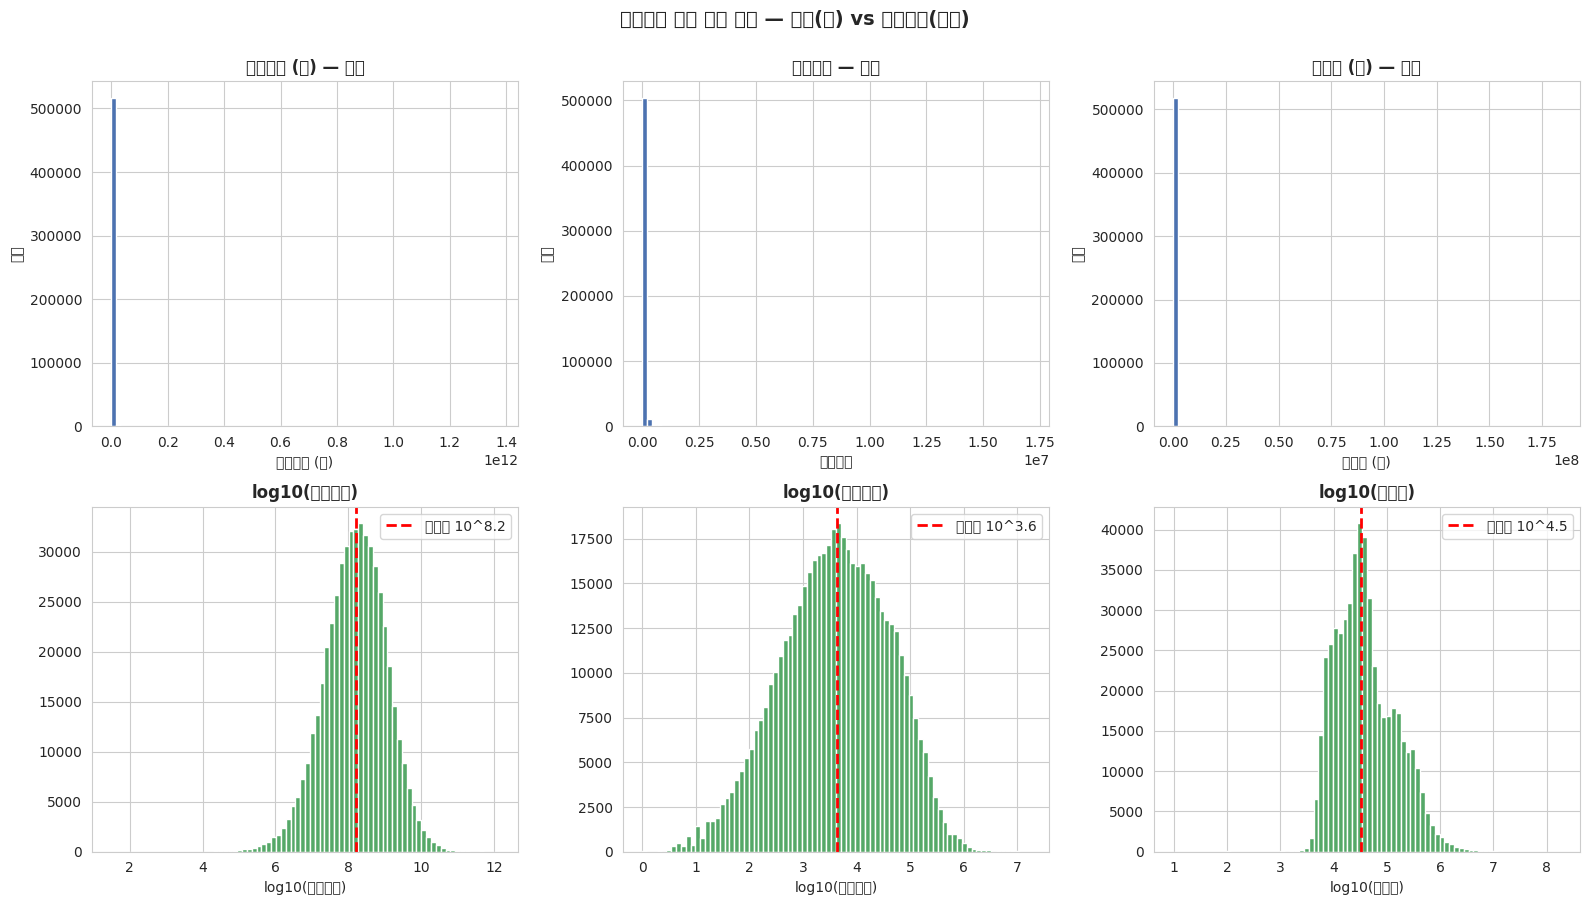

In [11]:
# 분포 시각화: 원본(위) vs 로그변환(아래)
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

# 행 1: 원본
for ax, (col, label) in zip(axes[0], [
    ('당월_매출_금액', '매출금액 (원)'),
    ('당월_매출_건수', '매출건수'),
    ('객단가', '객단가 (원)'),
]):
    ax.hist(sales[col].dropna(), bins=80, color='#4C72B0', edgecolor='white')
    ax.set_title(f'{label} — 원본', fontsize=12, fontweight='bold')
    ax.set_xlabel(label)
    ax.set_ylabel('빈도')
    ax.ticklabel_format(style='sci', axis='x', scilimits=(0,0))

# 행 2: 로그 변환
for ax, (col, label) in zip(axes[1], [
    ('당월_매출_금액', 'log10(매출금액)'),
    ('당월_매출_건수', 'log10(매출건수)'),
    ('객단가', 'log10(객단가)'),
]):
    log_data = np.log10(sales[col].dropna().clip(lower=1))
    ax.hist(log_data, bins=80, color='#55A868', edgecolor='white')
    ax.axvline(log_data.median(), color='red', linestyle='--', linewidth=2,
               label=f'중앙값 10^{log_data.median():.1f}')
    ax.set_title(label, fontsize=12, fontweight='bold')
    ax.set_xlabel(label)
    ax.legend()

plt.suptitle('추정매출 핵심 변수 분포 — 원본(위) vs 로그변환(아래)',
             fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font famil

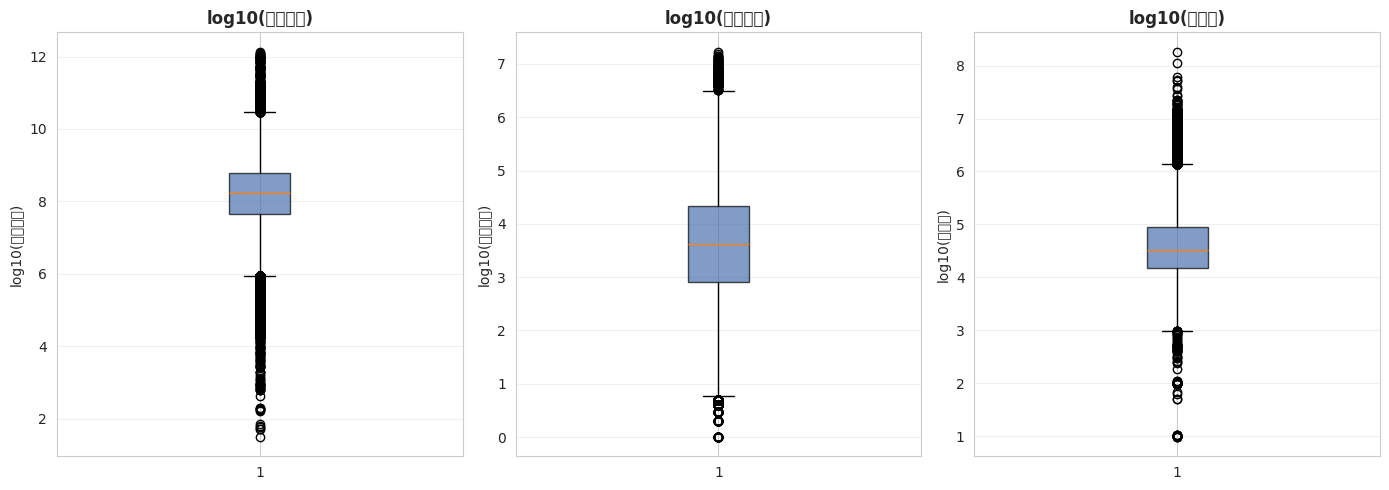

In [12]:
# 박스플롯 (로그 스케일)
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for ax, (col, label) in zip(axes, [
    ('당월_매출_금액', '매출금액'),
    ('당월_매출_건수', '매출건수'),
    ('객단가', '객단가'),
]):
    log_data = np.log10(sales[col].dropna().clip(lower=1))
    ax.boxplot(log_data, vert=True, patch_artist=True,
               boxprops=dict(facecolor='#4C72B0', alpha=0.7))
    ax.set_title(f'log10({label})', fontweight='bold')
    ax.set_ylabel(f'log10({label})')
    ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [13]:
# 왜도 (정규분포 정도) - -0.5~+0.5면 거의 정규
print('로그 변환 후 왜도 (skewness)')
print('기준: -0.5 ~ +0.5 → 정규분포에 가까움\n')
for col in ['당월_매출_금액','당월_매출_건수','객단가']:
    log_d = np.log10(sales[col].dropna().clip(lower=1))
    skew = log_d.skew()
    상태 = ' 정규에 가까움' if abs(skew) < 0.5 else '🟡 약간 치우침'
    print(f'  {col}: 왜도={skew:+.2f}  {상태}')

로그 변환 후 왜도 (skewness)
기준: -0.5 ~ +0.5 → 정규분포에 가까움

  당월_매출_금액: 왜도=-0.25   정규에 가까움
  당월_매출_건수: 왜도=-0.19   정규에 가까움
  객단가: 왜도=+0.56  🟡 약간 치우침


### Step 2 인사이트
- 원본 분포는 극단적 우편향 (long-tail) → 그대로 못 씀
- **로그 변환** 후 정규분포에 매우 근접 (왜도 절댓값 < 0.5)
- → **상권 발달 점수에서 매출 변수는 `log10(매출)` 후 min-max 정규화 사용**
- 메모: 

---
## Step 3: 상권 구분별 비교

목표:
- 영역 파일을 merge해서 자치구 정보 결합
- 상권 단위로 매출 집계
- **관광특구 / 발달상권 / 골목상권 / 전통시장** 4가지 그룹 비교
- 프로젝트의 핵심 질문: "골목 vs 일반 상권 불균형" 첫 정량 증거

In [14]:
# 영역 정보 merge
매출_영역 = sales.merge(
    area[['상권_코드','자치구_코드_명','행정동_코드_명','엑스좌표_값','와이좌표_값']],
    on='상권_코드', how='left'
)
print(f'merge 후: {매출_영역.shape}')
print(f'결측 자치구: {매출_영역["자치구_코드_명"].isna().sum()}')

merge 후: (519931, 60)
결측 자치구: 0


In [15]:
# 최신 분기로 필터 후 상권 단위 집계
최신분기 = 매출_영역[매출_영역['기준_년분기_코드']==최신_분기_코드]

상권집계 = 최신분기.groupby(
    ['상권_코드','상권_코드_명','상권_구분_코드_명','자치구_코드_명']
).agg(
    총매출=('당월_매출_금액','sum'),
    총건수=('당월_매출_건수','sum'),
    업종수=('서비스_업종_코드','nunique'),
).reset_index()

상권집계['객단가'] = 상권집계['총매출'] / 상권집계['총건수']
상권집계['log_매출'] = np.log10(상권집계['총매출'].clip(lower=1))
상권집계['총매출_억'] = (상권집계['총매출']/1e8).round(1)

print(f'분석 대상 상권: {len(상권집계):,}개')
상권집계.head()

분석 대상 상권: 1,565개


,상권_코드,상권_코드_명,상권_구분_코드_명,자치구_코드_명,총매출,총건수,업종수,객단가,log_매출,총매출_억
0,3001491,이태원 관광특구,관광특구,용산구,96748250708,3137664,33,"30,834.48",10.99,967.50
1,3001492,명동 남대문 북창동 다동 무교동 관광특구,관광특구,중구,537829815743,15760017,53,"34,126.22",11.73,"5,378.30"
2,3001493,동대문패션타운 관광특구,관광특구,중구,151636997858,4447433,39,"34,095.40",11.18,"1,516.40"
3,3001494,종로?청계 관광특구,관광특구,종로구,263865637195,6909787,53,"38,187.23",11.42,"2,638.70"
4,3001495,잠실 관광특구,관광특구,송파구,380932087468,13411055,42,"28,404.33",11.58,"3,809.30"


In [16]:
# 상권 구분별 요약 통계
구분통계 = 상권집계.groupby('상권_구분_코드_명').agg(
    상권수=('상권_코드','count'),
    평균매출=('총매출','mean'),
    중앙매출=('총매출','median'),
    평균객단가=('객단가','mean'),
    평균업종수=('업종수','mean'),
)
구분통계['평균매출_억'] = (구분통계['평균매출']/1e8).round(1)
구분통계['중앙매출_억'] = (구분통계['중앙매출']/1e8).round(1)
구분통계['평균객단가'] = 구분통계['평균객단가'].round(0)
구분통계['평균업종수'] = 구분통계['평균업종수'].round(1)
구분통계 = 구분통계.reindex(['관광특구','발달상권','전통시장','골목상권'])
구분통계[['상권수','평균매출_억','중앙매출_억','평균객단가','평균업종수']]

,상권수,평균매출_억,중앙매출_억,평균객단가,평균업종수
상권_구분_코드_명,,,,,
관광특구,6,"2,570.60","2,077.50","33,071.00",41.30
발달상권,249,599.60,348.40,"38,682.00",29.10
전통시장,280,138.00,46.90,"39,479.00",11.30
골목상권,1030,39.80,19.80,"42,542.00",10.40


findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font famil

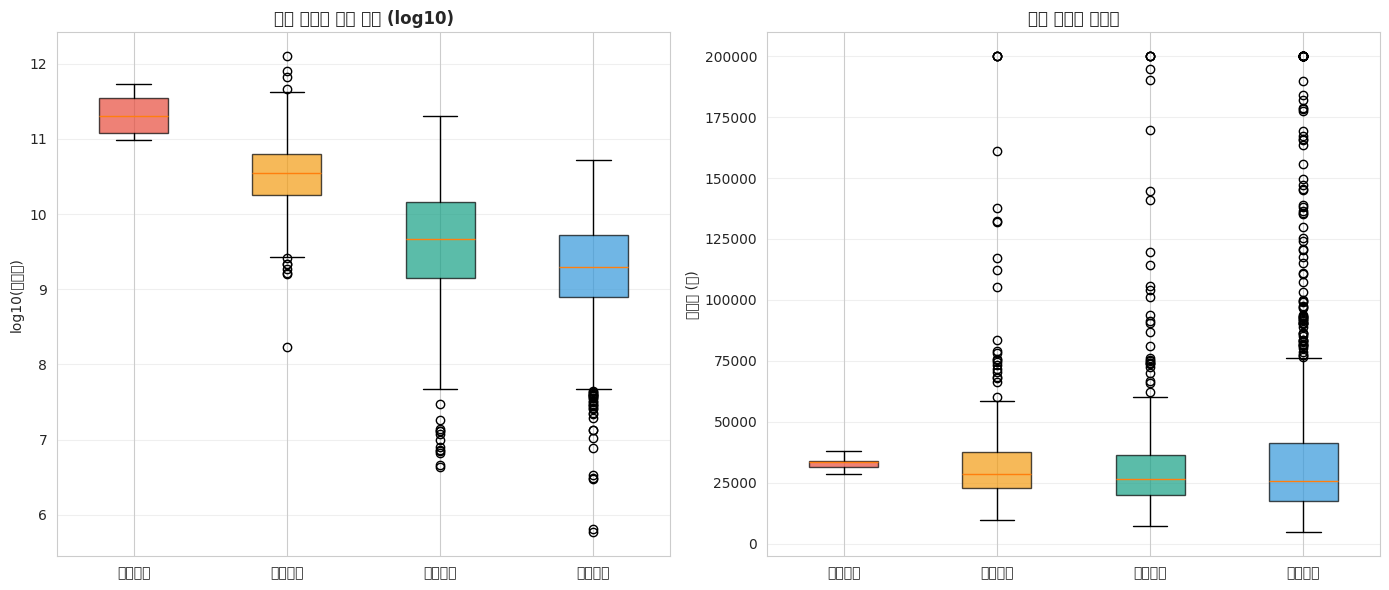

In [17]:
# 박스플롯: 상권 구분별 매출 vs 객단가
순서 = ['관광특구','발달상권','전통시장','골목상권']
색상 = ['#E74C3C','#F39C12','#16A085','#3498DB']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# (1) 매출 분포 (로그)
data1 = [상권집계[상권집계['상권_구분_코드_명']==g]['log_매출'].values for g in 순서]
bp1 = axes[0].boxplot(data1, labels=순서, patch_artist=True)
for patch, c in zip(bp1['boxes'], 색상):
    patch.set_facecolor(c); patch.set_alpha(0.7)
axes[0].set_title('상권 구분별 매출 분포 (log10)', fontweight='bold')
axes[0].set_ylabel('log10(총매출)')
axes[0].grid(axis='y', alpha=0.3)

# (2) 객단가 (200,000원 캡 - 이상치 가시성 향상)
data2 = [상권집계[상권집계['상권_구분_코드_명']==g]['객단가'].clip(upper=200000).values for g in 순서]
bp2 = axes[1].boxplot(data2, labels=순서, patch_artist=True)
for patch, c in zip(bp2['boxes'], 색상):
    patch.set_facecolor(c); patch.set_alpha(0.7)
axes[1].set_title('상권 구분별 객단가', fontweight='bold')
axes[1].set_ylabel('객단가 (원)')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [18]:
# 매출 TOP 20 상권
top20 = 상권집계.nlargest(20, '총매출')[
    ['상권_코드_명','상권_구분_코드_명','자치구_코드_명','총매출_억','업종수']
]
top20

,상권_코드_명,상권_구분_코드_명,자치구_코드_명,총매출_억,업종수
1188,노량진역(노량진),발달상권,동작구,"12,616.30",37
1166,가산디지털단지,발달상권,금천구,"8,043.80",51
1075,용산전자상가(용산역),발달상권,용산구,"6,689.90",32
1,명동 남대문 북창동 다동 무교동 관광특구,관광특구,중구,"5,378.30",53
1266,가락시장,발달상권,송파구,"4,592.10",10
1224,강남역,발달상권,서초구,"4,187.00",49
4,잠실 관광특구,관광특구,송파구,"3,809.30",42
1044,종로3가역,발달상권,종로구,"3,313.20",44
1262,잠실역,발달상권,송파구,"3,219.90",34
3,종로?청계 관광특구,관광특구,종로구,"2,638.70",53


findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font famil

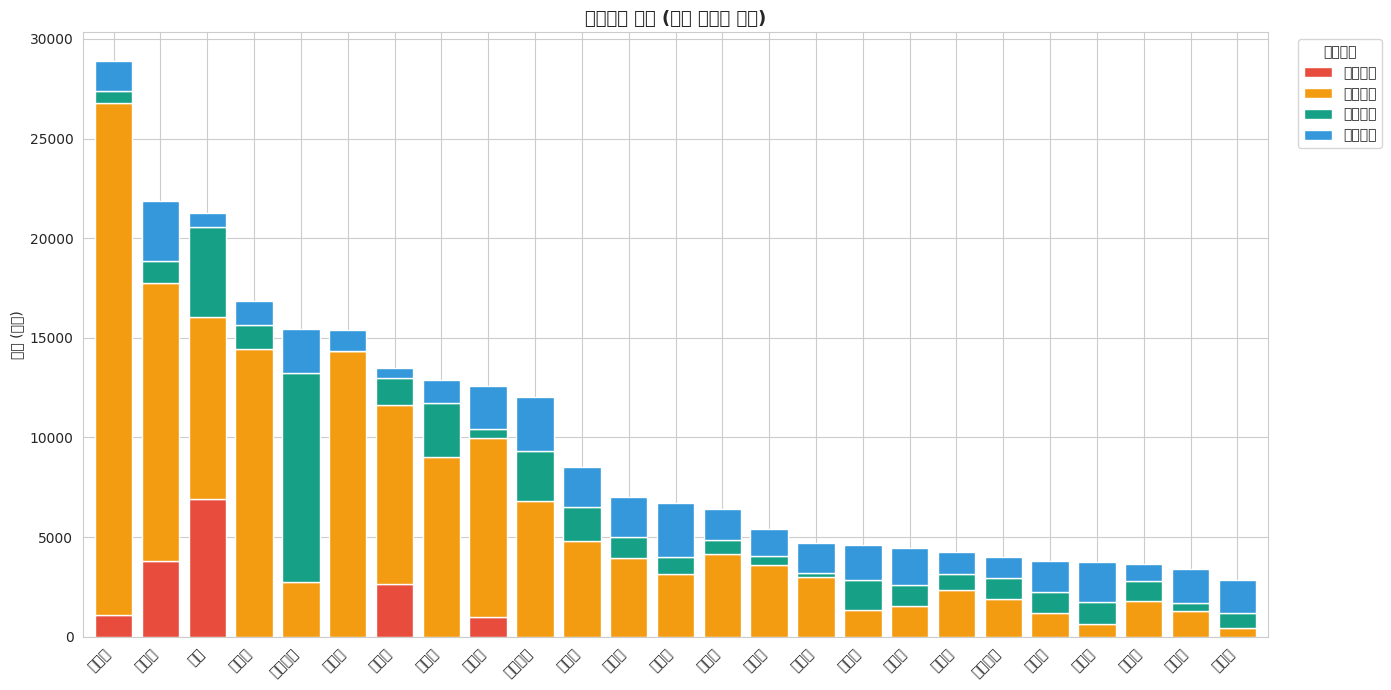

In [19]:
# 자치구별 총매출 + 상권 구분 분포
구별 = 상권집계.groupby(['자치구_코드_명','상권_구분_코드_명'])['총매출'].sum().unstack(fill_value=0)/1e8
구별['합계'] = 구별.sum(axis=1)
구별 = 구별.sort_values('합계', ascending=False)

fig, ax = plt.subplots(figsize=(14, 7))
구별_plot = 구별.drop('합계', axis=1)
구별_plot = 구별_plot[[c for c in 순서 if c in 구별_plot.columns]]
구별_plot.plot(kind='bar', stacked=True, ax=ax, color=색상, width=0.8)
ax.set_title('자치구별 매출 (상권 구분별 누적)', fontweight='bold', fontsize=13)
ax.set_ylabel('매출 (억원)')
ax.set_xlabel('')
ax.legend(title='상권구분', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 💡 Step 3 인사이트
- 관광특구가 평균 매출은 가장 높지만 **상권 수가 6개로 매우 적음** → 영향력 vs 면적 trade-off
- 골목상권 1,000여 개의 매출 분포와 발달상권 분포 비교
- 자치구별 매출 편차 → 어떤 구가 관광 매출 강자인지
- 메모: 

---
##  Step 4: 업종별 매출 패턴

목표:
- 100개 업종 중 매출 상위 업종 식별
- 어떤 업종이 어떤 상권 구분에서 강한지
- "관광객이 무엇을 사는지" 첫 단서

In [20]:
# 업종별 총매출 (최신 분기)
업종집계 = 최신분기.groupby(['서비스_업종_코드','서비스_업종_코드_명']).agg(
    총매출=('당월_매출_금액','sum'),
    총건수=('당월_매출_건수','sum'),
    상권수=('상권_코드','nunique'),
).reset_index()
업종집계['객단가'] = 업종집계['총매출']/업종집계['총건수']
업종집계['매출_억'] = (업종집계['총매출']/1e8).round(1)
업종집계 = 업종집계.sort_values('총매출', ascending=False)
print(f'업종 수: {len(업종집계)}')
업종집계.head(10)

업종 수: 62


,서비스_업종_코드,서비스_업종_코드_명,총매출,총건수,상권수,객단가,매출_억
0,CS100001,한식음식점,3985898301921,97348712,1406,"40,944.54","39,859.00"
40,CS300011,일반의류,2132212624743,29900054,850,"71,311.33","21,322.10"
14,CS200006,일반의원,1787685318222,32891128,518,"54,351.60","17,876.90"
45,CS300018,의약품,1426634468592,58776059,583,"24,272.37","14,266.30"
37,CS300008,수산물판매,1400689731246,21052006,130,"66,534.74","14,006.90"
38,CS300009,청과상,1281305234493,49080474,274,"26,106.21","12,813.10"
39,CS300010,반찬가게,856226080781,34798223,400,"24,605.45","8,562.30"
31,CS300001,슈퍼마켓,849778983467,74225863,888,"11,448.56","8,497.80"
36,CS300007,육류판매,807736979652,14832645,405,"54,456.71","8,077.40"
32,CS300002,편의점,806130121145,110658092,671,"7,284.87","8,061.30"


findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font famil

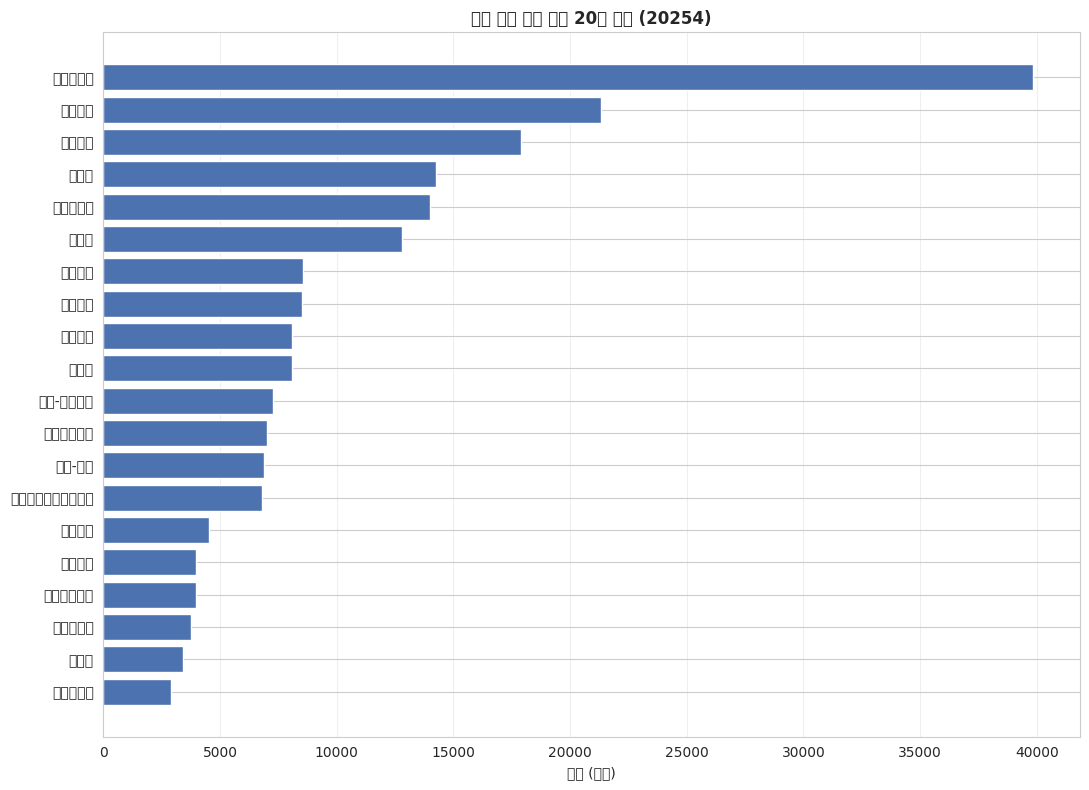

In [21]:
# TOP 20 업종 바차트
top20_업종 = 업종집계.head(20).copy()

fig, ax = plt.subplots(figsize=(11, 8))
ax.barh(top20_업종['서비스_업종_코드_명'][::-1], top20_업종['매출_억'][::-1], 
        color='#4C72B0', edgecolor='white')
ax.set_xlabel('매출 (억원)')
ax.set_title(f'서울 전체 매출 상위 20개 업종 ({최신_분기_코드})', fontweight='bold')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font famil

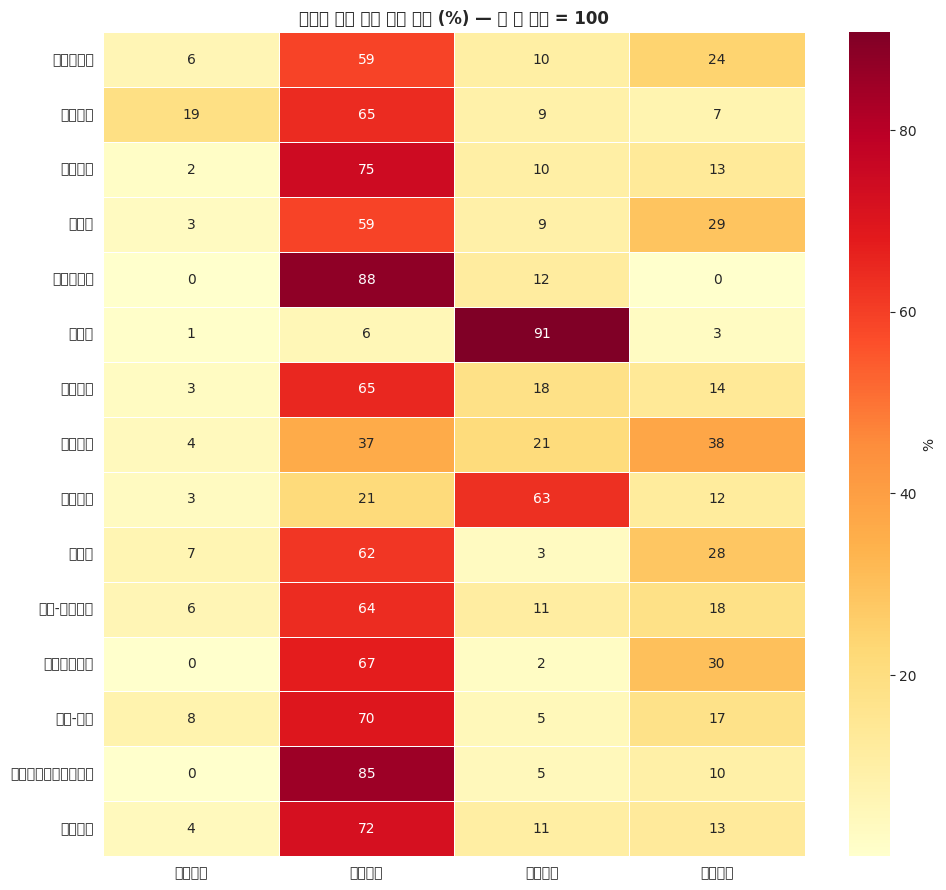

In [22]:
# 업종 × 상권구분 매출 비중 히트맵 (TOP 15 업종)
top15 = 업종집계.head(15)['서비스_업종_코드_명'].tolist()

sub = 최신분기[최신분기['서비스_업종_코드_명'].isin(top15)]
pivot = sub.pivot_table(
    values='당월_매출_금액',
    index='서비스_업종_코드_명',
    columns='상권_구분_코드_명',
    aggfunc='sum'
).fillna(0)/1e8

# 컬럼 순서 정렬
pivot = pivot[[c for c in 순서 if c in pivot.columns]]

# 각 업종 행을 100%로 정규화
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100
pivot_pct = pivot_pct.reindex(top15)

fig, ax = plt.subplots(figsize=(10, 9))
sns.heatmap(pivot_pct, annot=True, fmt='.0f', cmap='YlOrRd',
            cbar_kws={'label': '%'}, ax=ax, linewidths=0.5)
ax.set_title('업종별 상권 구분 매출 비중 (%) — 각 행 합계 = 100', 
             fontweight='bold', fontsize=12)
ax.set_xlabel('')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

In [23]:
# 관광특구에서 특히 강한 업종 (관광객 소비 패턴 단서)
관광특구_매출 = 최신분기[최신분기['상권_구분_코드_명']=='관광특구'].groupby(
    '서비스_업종_코드_명'
)['당월_매출_금액'].sum().sort_values(ascending=False)/1e8

print('🎯 관광특구 매출 TOP 15 업종 (단위: 억원)')
print(관광특구_매출.head(15).round(0))

🎯 관광특구 매출 TOP 15 업종 (단위: 억원)
서비스_업종_코드_명
일반의류      4,045.00
한식음식점     2,513.00
시계및귀금속      697.00
커피-음료       548.00
편의점         534.00
양식음식점       473.00
호프-간이주점     462.00
화장품         450.00
의약품         434.00
조명용품        379.00
슈퍼마켓        356.00
문구          354.00
운동/경기용품     339.00
중식음식점       276.00
일반의원        275.00
Name: 당월_매출_금액, dtype: float64


### Step 4 인사이트
- 매출 상위 업종은 무엇인가? (예상: 한식, 의류, 슈퍼마켓 등)
- 관광특구에 특화된 업종은? (예상: 화장품, 외국인 면세 관련)
- 골목상권 vs 관광특구의 업종 mix 차이
- 메모: 

---
## Step 5: 페르소나 분석 (성·연령·시간·요일)

목표:
- 상권 구분별로 누가/언제/어떻게 소비하는지
- 관광 상권은 평일/주말 패턴이 일상 상권과 다를 것
- 페르소나는 발달 점수 산출 후 클러스터링에도 활용 가능

findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font famil

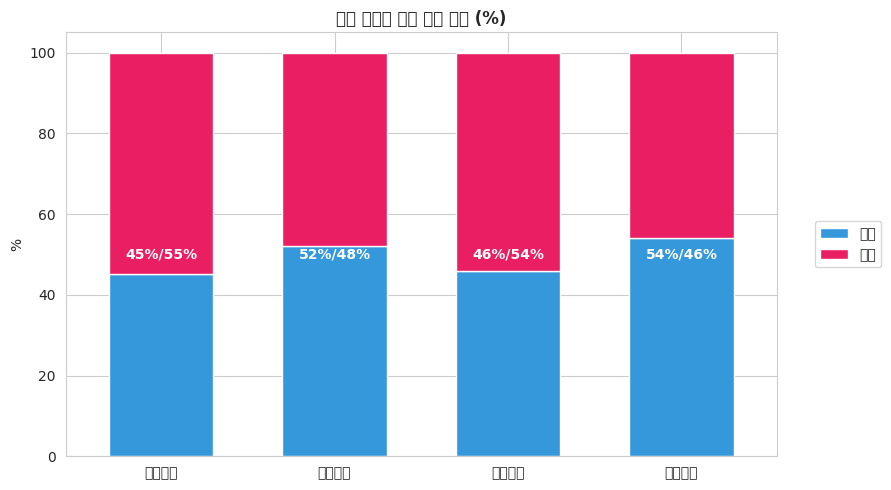

In [24]:
# 5-1. 성별 매출 비중
gender = 최신분기.groupby('상권_구분_코드_명').agg(
    남성=('남성_매출_금액','sum'),
    여성=('여성_매출_금액','sum'),
).reindex(순서)
gender_pct = gender.div(gender.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(9, 5))
gender_pct.plot(kind='bar', stacked=True, ax=ax, 
                color=['#3498DB','#E91E63'], width=0.6)
ax.set_title('상권 구분별 성별 매출 비중 (%)', fontweight='bold')
ax.set_ylabel('%')
ax.set_xlabel('')
ax.legend(loc='center', bbox_to_anchor=(1.1, 0.5))
plt.xticks(rotation=0)
for i, (idx, row) in enumerate(gender_pct.iterrows()):
    ax.text(i, 50, f'{row["남성"]:.0f}%/{row["여성"]:.0f}%',
            ha='center', va='center', color='white', fontweight='bold')
plt.tight_layout()
plt.show()

findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font famil

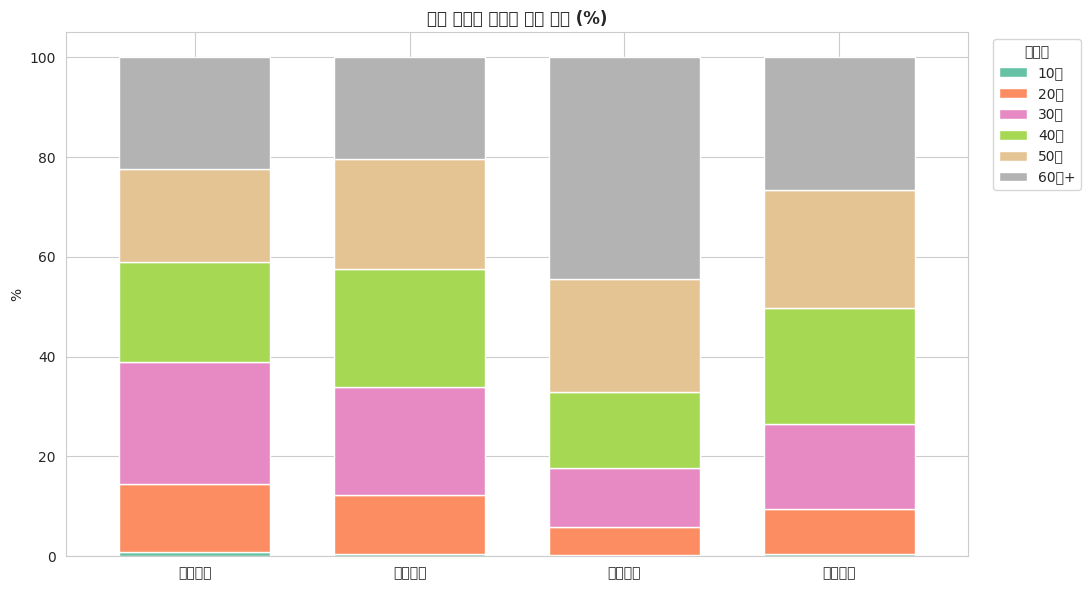


수치 (%)
            10대   20대   30대   40대   50대  60대+
상권_구분_코드_명                                   
관광특구       0.80 13.70 24.40 20.10 18.60 22.40
발달상권       0.50 11.70 21.60 23.70 22.10 20.30
전통시장       0.30  5.60 11.90 15.10 22.60 44.50
골목상권       0.50  9.00 17.00 23.30 23.50 26.70


In [25]:
# 5-2. 연령대별 매출 비중
연령컬럼 = ['연령대_10_매출_금액','연령대_20_매출_금액','연령대_30_매출_금액',
        '연령대_40_매출_금액','연령대_50_매출_금액','연령대_60_이상_매출_금액']
연령라벨 = ['10대','20대','30대','40대','50대','60대+']

age_data = 최신분기.groupby('상권_구분_코드_명')[연령컬럼].sum().reindex(순서)
age_data.columns = 연령라벨
age_pct = age_data.div(age_data.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(11, 6))
age_pct.plot(kind='bar', stacked=True, ax=ax, 
             colormap='Set2', width=0.7, edgecolor='white')
ax.set_title('상권 구분별 연령대 매출 비중 (%)', fontweight='bold')
ax.set_ylabel('%')
ax.set_xlabel('')
ax.legend(title='연령대', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print('\n수치 (%)')
print(age_pct.round(1))

findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font famil

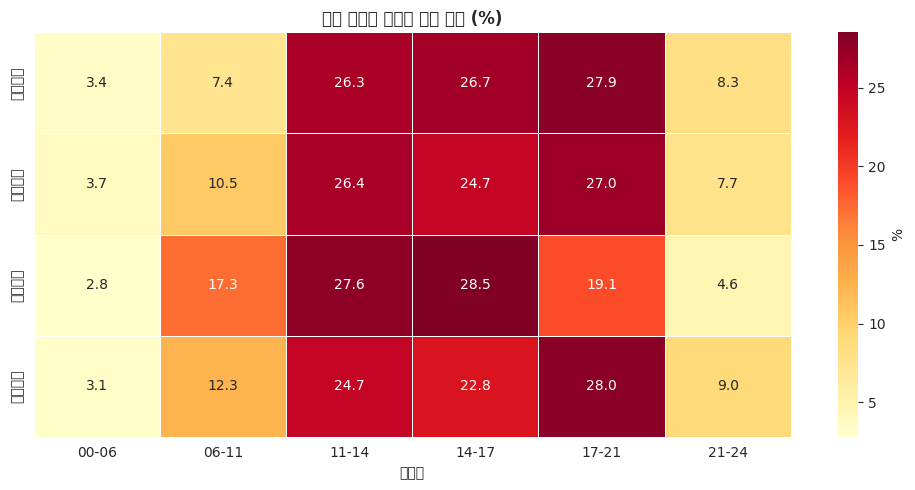

In [26]:
# 5-3. 시간대별 매출 비중 (히트맵)
시간컬럼 = ['시간대_00~06_매출_금액','시간대_06~11_매출_금액','시간대_11~14_매출_금액',
        '시간대_14~17_매출_금액','시간대_17~21_매출_금액','시간대_21~24_매출_금액']
시간라벨 = ['00-06','06-11','11-14','14-17','17-21','21-24']

time_data = 최신분기.groupby('상권_구분_코드_명')[시간컬럼].sum().reindex(순서)
time_data.columns = 시간라벨
time_pct = time_data.div(time_data.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(time_pct, annot=True, fmt='.1f', cmap='YlOrRd',
            cbar_kws={'label': '%'}, ax=ax, linewidths=0.5)
ax.set_title('상권 구분별 시간대 매출 비중 (%)', fontweight='bold')
ax.set_xlabel('시간대')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font famil

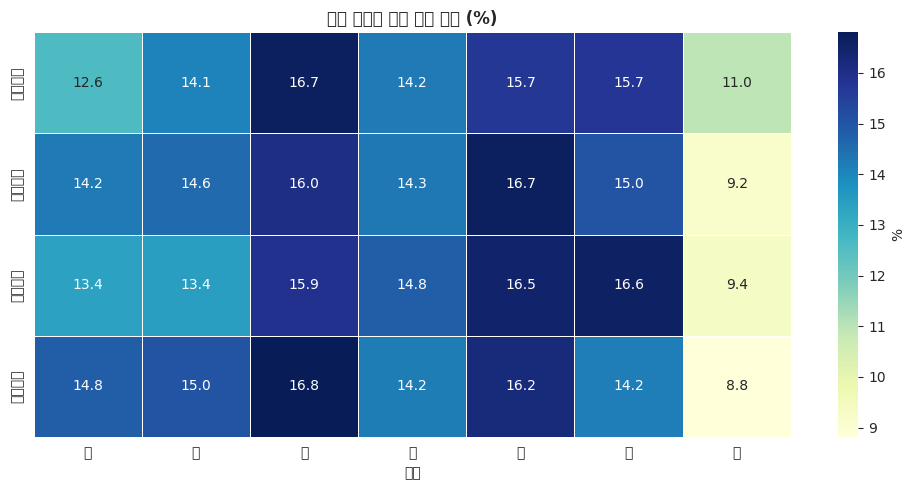


 주말(토+일) 매출 비중
상권_구분_코드_명
관광특구   26.70
발달상권   24.20
전통시장   26.00
골목상권   23.00
dtype: float64

→ 기준: 일상적 분포는 ~28.6% (1/7×2), 관광 상권은 더 높을 것


In [27]:
# 5-4. 요일별 매출 비중 (히트맵)
요일컬럼 = ['월요일_매출_금액','화요일_매출_금액','수요일_매출_금액','목요일_매출_금액',
        '금요일_매출_금액','토요일_매출_금액','일요일_매출_금액']
요일라벨 = ['월','화','수','목','금','토','일']

day_data = 최신분기.groupby('상권_구분_코드_명')[요일컬럼].sum().reindex(순서)
day_data.columns = 요일라벨
day_pct = day_data.div(day_data.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(day_pct, annot=True, fmt='.1f', cmap='YlGnBu',
            cbar_kws={'label': '%'}, ax=ax, linewidths=0.5)
ax.set_title('상권 구분별 요일 매출 비중 (%)', fontweight='bold')
ax.set_xlabel('요일')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

# 주말 비중 (토+일)
주말비중 = (day_pct['토'] + day_pct['일']).round(1)
print('\n 주말(토+일) 매출 비중')
print(주말비중)
print('\n→ 기준: 일상적 분포는 ~28.6% (1/7×2), 관광 상권은 더 높을 것')

### Step 5 인사이트
- 관광특구는 주말 비중이 골목상권보다 얼마나 높은가?
- 어떤 상권이 어느 연령대에 강한가?
- 시간대 패턴: 관광 vs 직장가 vs 주거지
- 메모: 

---
## Step 6: 시계열 트렌드 (2020~2025)

목표:
- 분기별 매출 추이
- 코로나 충격(2020~2021) → 회복(2022~)
- 상권 구분별 회복 속도 차이

findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font famil

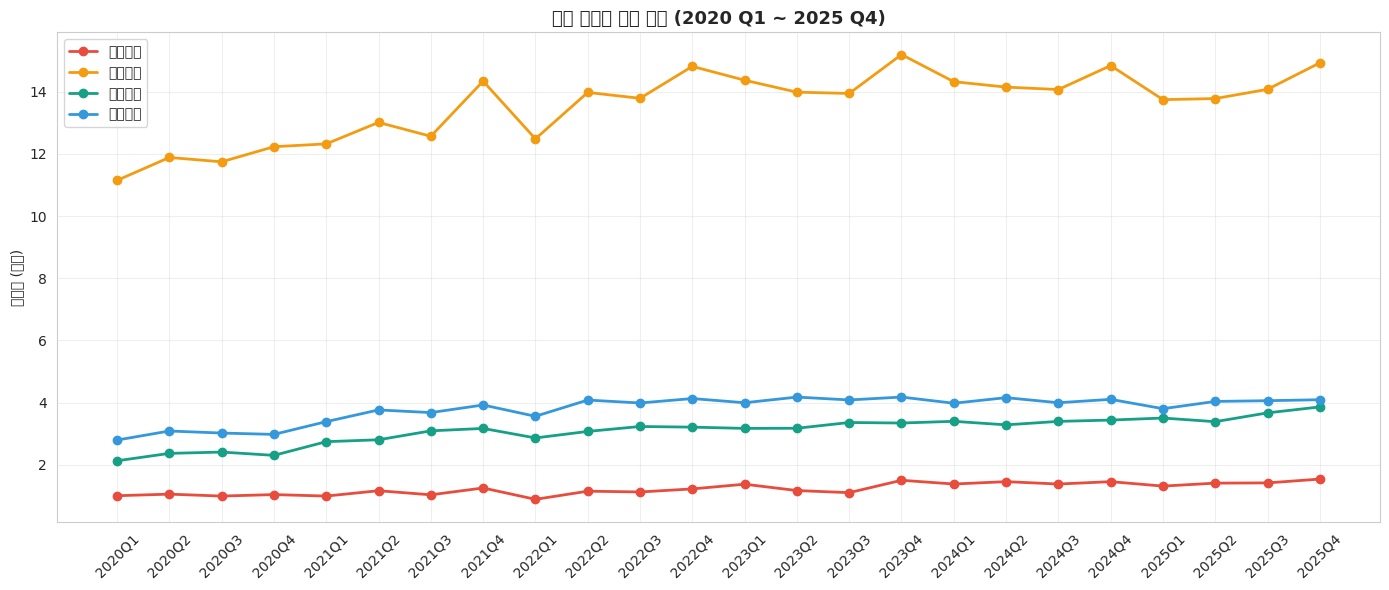

In [28]:
# 분기별 상권 구분별 총매출
trend = 매출_영역.groupby(['기준_년분기_코드','상권_구분_코드_명'])['당월_매출_금액'].sum().reset_index()
trend['매출_조'] = trend['당월_매출_금액']/1e12

# 라벨용 (예: 20221 → 2022Q1)
def to_label(q):
    return f'{q//10}Q{q%10}'
trend['분기라벨'] = trend['기준_년분기_코드'].apply(to_label)

fig, ax = plt.subplots(figsize=(14, 6))
for grp, color in zip(순서, 색상):
    sub = trend[trend['상권_구분_코드_명']==grp].sort_values('기준_년분기_코드')
    ax.plot(sub['분기라벨'], sub['매출_조'], 
            marker='o', label=grp, linewidth=2, color=color)
ax.set_title('상권 구분별 매출 추이 (2020 Q1 ~ 2025 Q4)', fontweight='bold', fontsize=13)
ax.set_ylabel('총매출 (조원)')
ax.set_xlabel('')
ax.legend(loc='best')
ax.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [29]:
# 코로나 전후 회복률 (2020 Q1 → 2025 Q4)
period = 매출_영역[매출_영역['기준_년분기_코드'].isin([20201, 20254])].groupby(
    ['기준_년분기_코드','상권_구분_코드_명']
)['당월_매출_금액'].sum().unstack(0)
period.columns = ['2020Q1','2025Q4']
period['성장률(%)'] = ((period['2025Q4']/period['2020Q1']-1)*100).round(1)
period['2020Q1_조'] = (period['2020Q1']/1e12).round(2)
period['2025Q4_조'] = (period['2025Q4']/1e12).round(2)
period = period.reindex(순서)
period[['2020Q1_조','2025Q4_조','성장률(%)']]

,2020Q1_조,2025Q4_조,성장률(%)
상권_구분_코드_명,,,
관광특구,1.01,1.54,53.10
발달상권,11.15,14.93,33.90
전통시장,2.13,3.86,81.30
골목상권,2.80,4.09,46.40


findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font famil

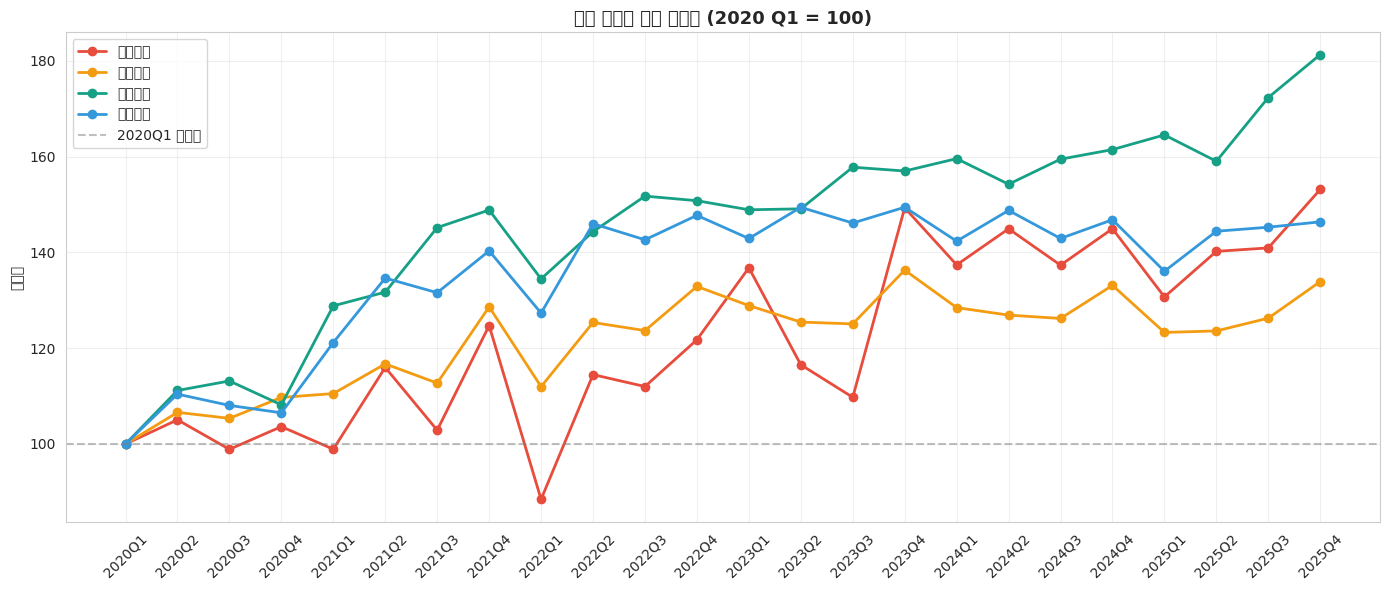

In [30]:
# 분기별 인덱스 (2020Q1 = 100) - 회복 속도 비교용
base = trend[trend['기준_년분기_코드']==20201].set_index('상권_구분_코드_명')['당월_매출_금액']
trend['인덱스'] = trend.apply(
    lambda r: r['당월_매출_금액']/base[r['상권_구분_코드_명']]*100, axis=1
)

fig, ax = plt.subplots(figsize=(14, 6))
for grp, color in zip(순서, 색상):
    sub = trend[trend['상권_구분_코드_명']==grp].sort_values('기준_년분기_코드')
    ax.plot(sub['분기라벨'], sub['인덱스'], 
            marker='o', label=grp, linewidth=2, color=color)
ax.axhline(100, color='gray', linestyle='--', alpha=0.5, label='2020Q1 기준선')
ax.set_title('상권 구분별 매출 인덱스 (2020 Q1 = 100)', fontweight='bold', fontsize=13)
ax.set_ylabel('인덱스')
ax.set_xlabel('')
ax.legend(loc='best')
ax.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [31]:
# 연도별 총매출 (분기별 합산을 연 단위로)
매출_영역['연도'] = 매출_영역['기준_년분기_코드']//10
연도별 = 매출_영역.groupby(['연도','상권_구분_코드_명'])['당월_매출_금액'].sum().unstack()/1e12
연도별 = 연도별[순서]
연도별.round(2)

상권_구분_코드_명,관광특구,발달상권,전통시장,골목상권
연도,,,,
2020,4.10,47.01,9.22,11.89
2021,4.46,52.25,11.82,14.76
2022,4.40,55.07,12.39,15.77
2023,5.16,57.50,13.06,16.44
2024,5.69,57.39,13.52,16.25
2025,5.69,56.53,14.43,16.00


### Step 6 인사이트
- 관광특구는 코로나 충격이 가장 컸을 것 (외국인 입국 막힘)
- 2022~2023년 회복 시작, 2024~2025년 정상화 추세 예상
- 골목상권은 상대적으로 안정적이었을 가능성 (지역 주민 수요)
- 발달상권은 직장가 중심 → 재택근무 영향 가능
- 메모: 

## 나경 EDA - 상권변화지표

In [34]:
from pathlib import Path
import pandas as pd

csv_file = list(Path("data").rglob("*상권변화지표*.csv"))[0]

df = pd.read_csv(csv_file, encoding="cp949")

print(csv_file)
print(f"✅ 로드 완료: {df.shape}")

data/extracted/서울시 상권분석서비스(상권변화지표-상권)/서울시 상권분석서비스(상권변화지표-상권).csv
✅ 로드 완료: (46200, 11)


from pathlib import Path

current = Path.cwd()
project_root = current if (current / 'data').exists() else current.parent

csv_path = project_root / 'data' / '08_상권변화지표' / '서울시 상권분석서비스(상권변화지표-상권).csv'

df = pd.read_csv(csv_path, encoding='cp949')
print(f'✅ 로드 완료: {df.shape}')

In [36]:
# 기본 정보 확인
print("shape:", df.shape)
print()
print("columns:", df.columns.tolist())
print()
print("dtypes:")
print(df.dtypes)

shape: (46200, 11)

columns: ['기준_년분기_코드', '상권_구분_코드', '상권_구분_코드_명', '상권_코드', '상권_코드_명', '상권_변화_지표', '상권_변화_지표_명', '운영_영업_개월_평균', '폐업_영업_개월_평균', '서울_운영_영업_개월_평균', '서울_폐업_영업_개월_평균']

dtypes:
기준_년분기_코드         int64
상권_구분_코드            str
상권_구분_코드_명          str
상권_코드             int64
상권_코드_명             str
상권_변화_지표            str
상권_변화_지표_명          str
운영_영업_개월_평균       int64
폐업_영업_개월_평균       int64
서울_운영_영업_개월_평균    int64
서울_폐업_영업_개월_평균    int64
dtype: object


In [ ]:
# 결측치 확인
print("결측치:")
print(df.isnull().sum())
print()

# 기본 통계
df.describe()

결측치:
기준_년분기_코드         0
상권_구분_코드          0
상권_구분_코드_명        0
상권_코드             0
상권_코드_명           0
상권_변화_지표          0
상권_변화_지표_명        0
운영_영업_개월_평균       0
폐업_영업_개월_평균       0
서울_운영_영업_개월_평균    0
서울_폐업_영업_개월_평균    0
dtype: int64



,기준_년분기_코드,상권_코드,운영_영업_개월_평균,폐업_영업_개월_평균,서울_운영_영업_개월_평균,서울_폐업_영업_개월_평균
count,"46,200.00","46,200.00","46,200.00","46,200.00","46,200.00","46,200.00"
mean,"20,222.50","3,115,221.90",105.05,51.44,99.71,50.36
std,20.03,"10,318.64",25.40,10.18,7.03,1.59
min,"20,191.00","3,001,491.00",0.00,17.00,92.00,48.00
25%,"20,203.75","3,110,407.00",90.00,46.00,93.00,49.00
50%,"20,222.50","3,110,819.50",101.00,50.00,98.50,50.00
75%,"20,241.25","3,120,142.00",116.00,55.00,103.50,52.00
max,"20,254.00","3,130,327.00",351.00,226.00,115.00,53.00


## 기본정보
- 행: 46,200개 / 컬럼: 11개
- 결측치: 없음 

## 주요 통계
- 운영_영업_개월_평균: 평균 105개월 (약 8.7년), 최대 351개월 (약 29년)
- 폐업_영업_개월_평균: 평균 51개월 (약 4.3년)
- 서울_운영_영업_개월_평균: 평균 99개월 (서울 전체 기준)
- 서울_폐업_영업_개월_평균: 평균 50개월 (서울 전체 기준)

##  이상치 의심
- 운영_영업_개월_평균 최솟값 0개월 → 추후 확인 필요

In [ ]:
# 연도/분기 고유값 확인
print("기준_년분기_코드 고유값:")
print(sorted(df['기준_년분기_코드'].unique()))
print()

# 상권 유형 고유값 확인
print("상권_구분_코드_명 고유값:")
print(df['상권_구분_코드_명'].unique())
print()

# 상권 변화 지표 고유값 확인
print("상권_변화_지표_명 고유값:")
print(df['상권_변화_지표_명'].unique())

기준_년분기_코드 고유값:
[np.int64(20191), np.int64(20192), np.int64(20193), np.int64(20194), np.int64(20201), np.int64(20202), np.int64(20203), np.int64(20204), np.int64(20211), np.int64(20212), np.int64(20213), np.int64(20214), np.int64(20221), np.int64(20222), np.int64(20223), np.int64(20224), np.int64(20231), np.int64(20232), np.int64(20233), np.int64(20234), np.int64(20241), np.int64(20242), np.int64(20243), np.int64(20244), np.int64(20251), np.int64(20252), np.int64(20253), np.int64(20254)]

상권_구분_코드_명 고유값:
<StringArray>
['관광특구', '전통시장', '발달상권', '골목상권']
Length: 4, dtype: str

상권_변화_지표_명 고유값:
<StringArray>
['정체', '다이나믹', '상권확장', '상권축소']
Length: 4, dtype: str


## 카테고리 값 확인
- 기간: 2019 Q1 ~ 2025 Q4 (28개 분기) ✅
- 상권 유형: 관광특구 / 전통시장 / 발달상권 / 골목상권
- 변화 지표: 상권확장 / 상권축소 / 다이나믹 / 정체

In [ ]:
# 팀원 데이터 JOIN 키 형식 확인
print("상권_코드 샘플:", df['상권_코드'].head().tolist())
print("상권_코드 타입:", df['상권_코드'].dtype)
print()
print("기준_년분기_코드 샘플:", df['기준_년분기_코드'].head().tolist())
print("기준_년분기_코드 타입:", df['기준_년분기_코드'].dtype)

상권_코드 샘플: [3001496, 3001495, 3001494, 3001493, 3001492]
상권_코드 타입: int64

기준_년분기_코드 샘플: [20254, 20254, 20254, 20254, 20254]
기준_년분기_코드 타입: int64


## JOIN 키 확인
- 상권_코드: int형, 예) 1000001 형태
- 기준_년분기_코드: int형, 예) 20191 형태
- 키 형식 동일한지 합칠 때 재확인 필요

In [ ]:
# 분석 기간 필터링 (2019~2024만 사용)
df = df[df['기준_년분기_코드'] < 20250]

In [ ]:
# 상위 5개 데이터 확인
df.head()

,기준_년분기_코드,상권_구분_코드,상권_구분_코드_명,상권_코드,상권_코드_명,상권_변화_지표,상권_변화_지표_명,운영_영업_개월_평균,폐업_영업_개월_평균,서울_운영_영업_개월_평균,서울_폐업_영업_개월_평균
6600,20244,U,관광특구,3001496,강남 마이스 관광특구,HH,정체,116,66,109,52
6601,20244,U,관광특구,3001495,잠실 관광특구,LL,다이나믹,94,51,109,52
6602,20244,U,관광특구,3001494,종로?청계 관광특구,HH,정체,163,73,109,52
6603,20244,U,관광특구,3001493,동대문패션타운 관광특구,HH,정체,116,62,109,52
6604,20244,U,관광특구,3001492,명동 남대문 북창동 다동 무교동 관광특구,HH,정체,141,65,109,52


In [ ]:
# 상권_변화_지표 고유값 확인
print(df['상권_변화_지표'].unique())

<StringArray>
['HH', 'LL', 'LH', 'HL']
Length: 4, dtype: str


## 상권_변화_지표 코드 의미
- HH (정체): 운영↑ 폐업↑ - 변화 적은 상권
- LL (다이나믹): 운영↓ 폐업↓ - 빠른 회전 상권
- HL (상권확장): 운영↑ 폐업↓ - 성장 중인 상권
- LH (상권축소): 운영↓ 폐업↑ - 취약상권 후보 

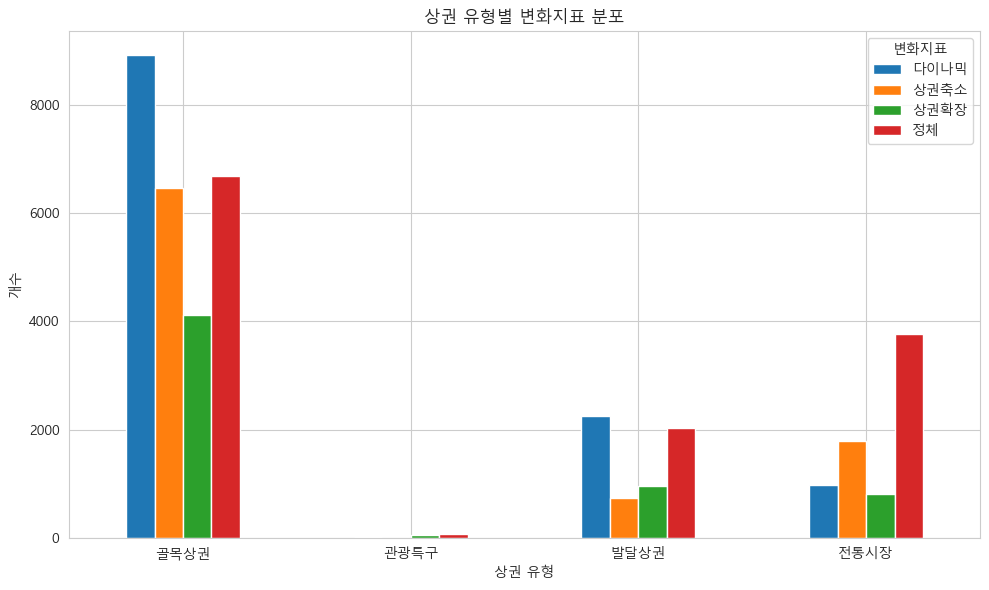

In [ ]:
# 상권 유형별 변화지표 분포 시각화
fig, ax = plt.subplots(figsize=(10, 6))

# 상권 유형별 변화지표 개수 계산
pivot = df.groupby(['상권_구분_코드_명', '상권_변화_지표_명']).size().unstack()

# 막대 그래프
pivot.plot(kind='bar', ax=ax)


ax.set_title('상권 유형별 변화지표 분포')
ax.set_xlabel('상권 유형')
ax.set_ylabel('개수')
ax.legend(title='변화지표')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 상권 유형별 변화지표 분포
- 골목상권: 다이나믹 비율 가장 높음 → 빠른 개폐업 반복, 불안정
- 관광특구: 데이터 수 적음 → 상권 수 자체가 적음
- 발달상권: 다이나믹 + 정체 혼재
- 전통시장: 정체 비율 압도적 → 변화 없는 고착형 상권

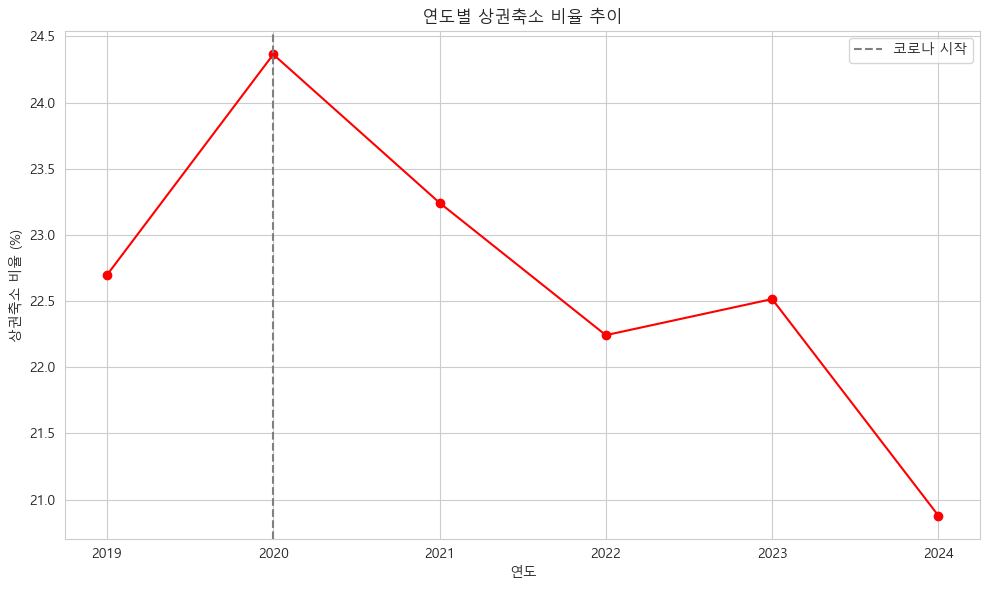

In [ ]:
# 연도별 상권축소 비율 추이
# 분기코드에서 연도만 추출
df['연도'] = df['기준_년분기_코드'].astype(str).str[:4].astype(int)

# 연도별 상권축소 비율 계산
total = df.groupby('연도').size()
축소 = df[df['상권_변화_지표_명'] == '상권축소'].groupby('연도').size()
축소_비율 = (축소 / total * 100).reset_index()
축소_비율.columns = ['연도', '상권축소_비율']

# 그래프
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(축소_비율['연도'], 축소_비율['상권축소_비율'], marker='o', color='red')

# 코로나 시점 표시
ax.axvline(x=2020, color='gray', linestyle='--', label='코로나 시작')

ax.set_title('연도별 상권축소 비율 추이')
ax.set_xlabel('연도')
ax.set_ylabel('상권축소 비율 (%)')
ax.legend()
plt.tight_layout()
plt.show()

## 연도별 상권축소 비율 추이
- 2020년 코로나 타격으로 상권축소 비율 최고점(24.4%)
- 2022년부터 회복세
- 2024~2025년 역대 최저(21%) → 코로나 이전보다 오히려 개선

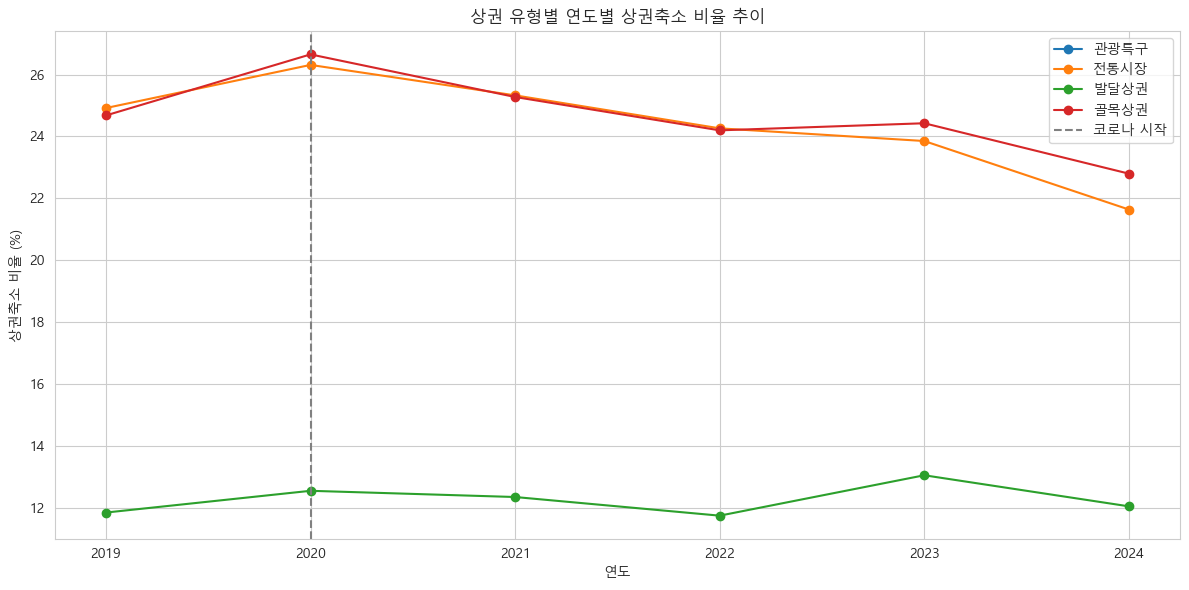

In [ ]:
# 상권 유형별 연도별 축소 비율 추이
fig, ax = plt.subplots(figsize=(12, 6))

# 유형별로 연도별 축소 비율 계산
for 유형 in df['상권_구분_코드_명'].unique():
    df_유형 = df[df['상권_구분_코드_명'] == 유형]
    total = df_유형.groupby('연도').size()
    축소 = df_유형[df_유형['상권_변화_지표_명'] == '상권축소'].groupby('연도').size()
    비율 = (축소 / total * 100)
    ax.plot(비율.index, 비율.values, marker='o', label=유형)

# 코로나 시점 표시
ax.axvline(x=2020, color='gray', linestyle='--', label='코로나 시작')

ax.set_title('상권 유형별 연도별 상권축소 비율 추이')
ax.set_xlabel('연도')
ax.set_ylabel('상권축소 비율 (%)')
ax.legend()
plt.tight_layout()
plt.show()

## 상권 유형별 연도별 상권축소 비율 추이
- 전 유형 2020년 코로나로 최고점
- 발달상권: 타격 가장 적음 (12%대 유지)
- 전통시장: 회복 속도 가장 빠름
- 골목상권: 여전히 높은 축소 비율 → 가장 취약 

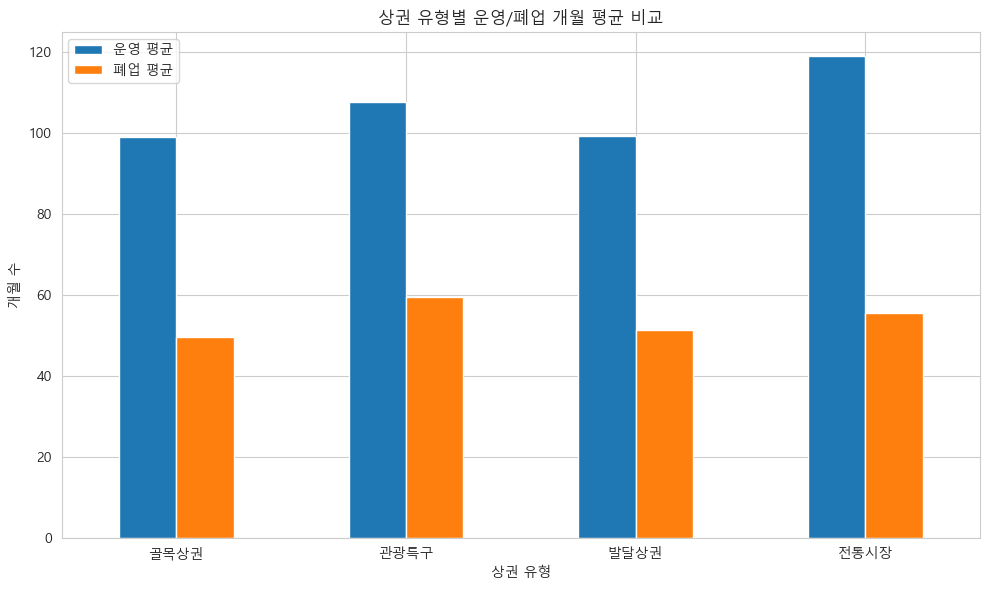

In [ ]:
# 상권 유형별 운영/폐업 개월 평균 비교
fig, ax = plt.subplots(figsize=(10, 6))

# 유형별 평균 계산
평균 = df.groupby('상권_구분_코드_명')[['운영_영업_개월_평균', '폐업_영업_개월_평균']].mean()

# 막대 그래프
평균.plot(kind='bar', ax=ax)

ax.set_title('상권 유형별 운영/폐업 개월 평균 비교')
ax.set_xlabel('상권 유형')
ax.set_ylabel('개월 수')
ax.legend(['운영 평균', '폐업 평균'])
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 상권 유형별 운영/폐업 개월 평균 비교
- 전통시장: 운영 평균 121개월(약 10년)로 가장 길음 → 고착형 상권
- 관광특구: 폐업까지 가장 오래 버팀 (60개월)
- 골목/발달상권: 운영 평균 유사 (약 101개월)

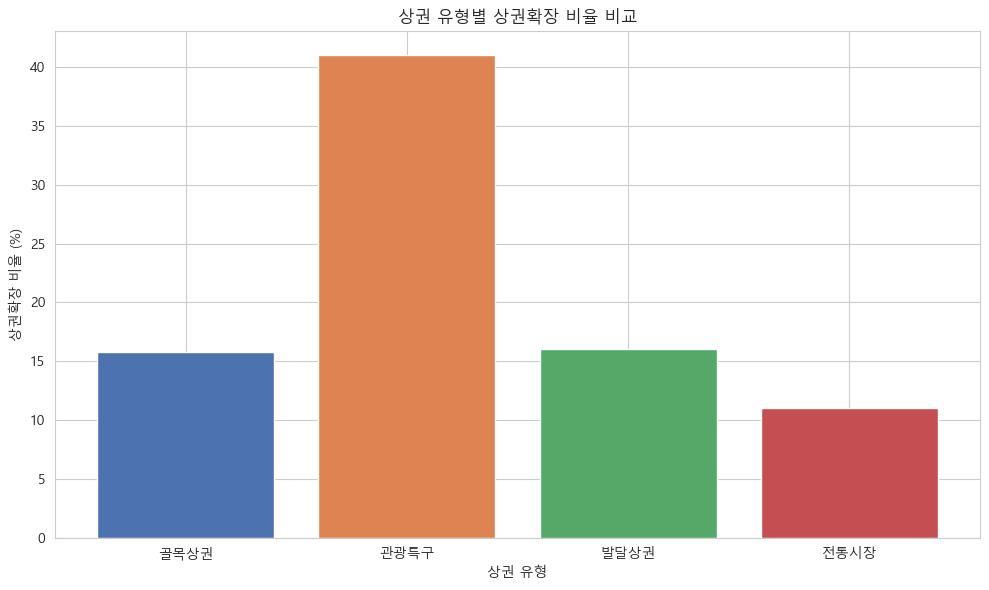

In [ ]:
# 상권 유형별 상권확장 비율 비교
fig, ax = plt.subplots(figsize=(10, 6))

# 유형별 상권확장 비율 계산
total = df.groupby('상권_구분_코드_명').size()
확장 = df[df['상권_변화_지표_명'] == '상권확장'].groupby('상권_구분_코드_명').size()
확장_비율 = (확장 / total * 100).reset_index()
확장_비율.columns = ['상권_구분_코드_명', '상권확장_비율']

# 막대 그래프
ax.bar(확장_비율['상권_구분_코드_명'], 확장_비율['상권확장_비율'], color=['#4C72B0', '#DD8452', '#55A868', '#C44E52'])

ax.set_title('상권 유형별 상권확장 비율 비교')
ax.set_xlabel('상권 유형')
ax.set_ylabel('상권확장 비율 (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 상권 유형별 상권확장 비율 비교
- 관광특구: 37%로 압도적 1위 → 성장 잠재력 가장 강함
- 골목/발달상권: 16%로 유사
- 전통시장: 11%로 가장 낮음 → 고착형, 정책 지원 필요 

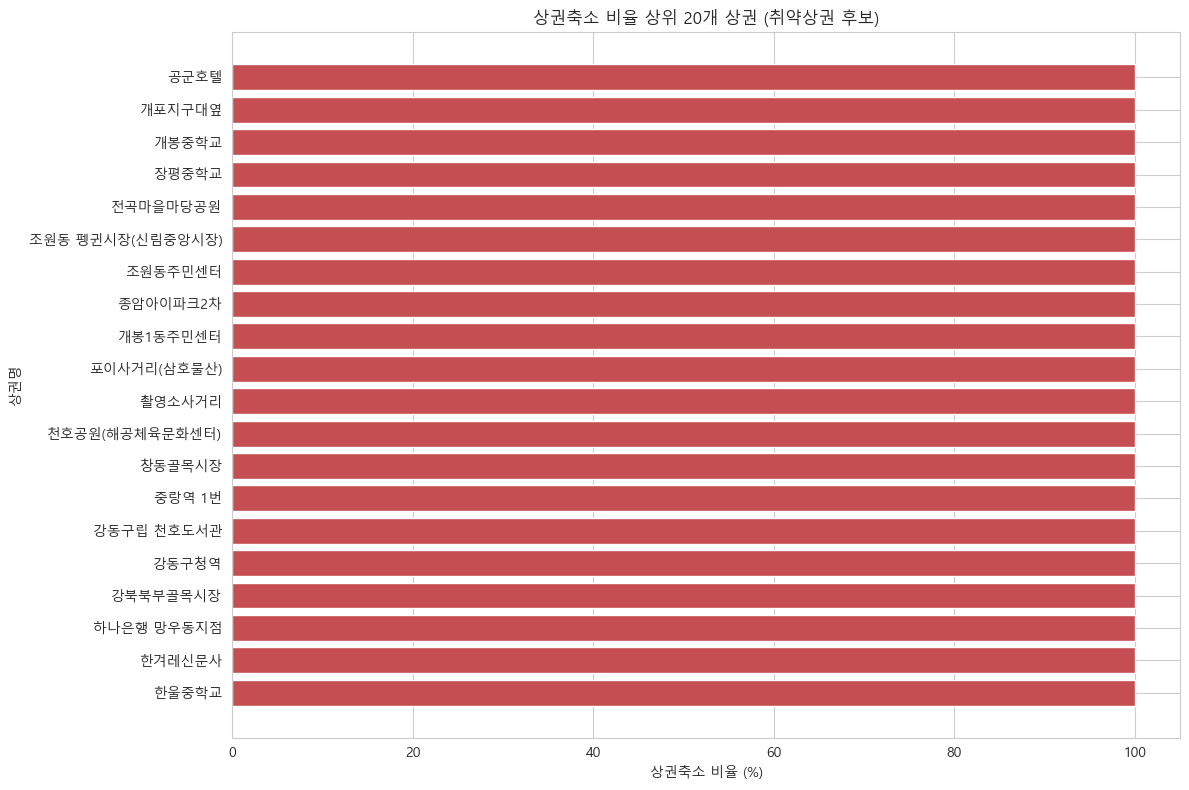

In [ ]:
# 취약상권 후보 추출 (상권축소 비율 상위 상권 목록)
fig, ax = plt.subplots(figsize=(12, 8))

# 상권별 전체 분기 중 상권축소 비율 계산
total = df.groupby('상권_코드_명').size()
축소 = df[df['상권_변화_지표_명'] == '상권축소'].groupby('상권_코드_명').size()
축소_비율 = (축소 / total * 100).dropna().sort_values(ascending=False).head(20)

# 가로 막대 그래프
ax.barh(축소_비율.index, 축소_비율.values, color='#C44E52')

ax.set_title('상권축소 비율 상위 20개 상권 (취약상권 후보)')
ax.set_xlabel('상권축소 비율 (%)')
ax.set_ylabel('상권명')
plt.tight_layout()
plt.show()

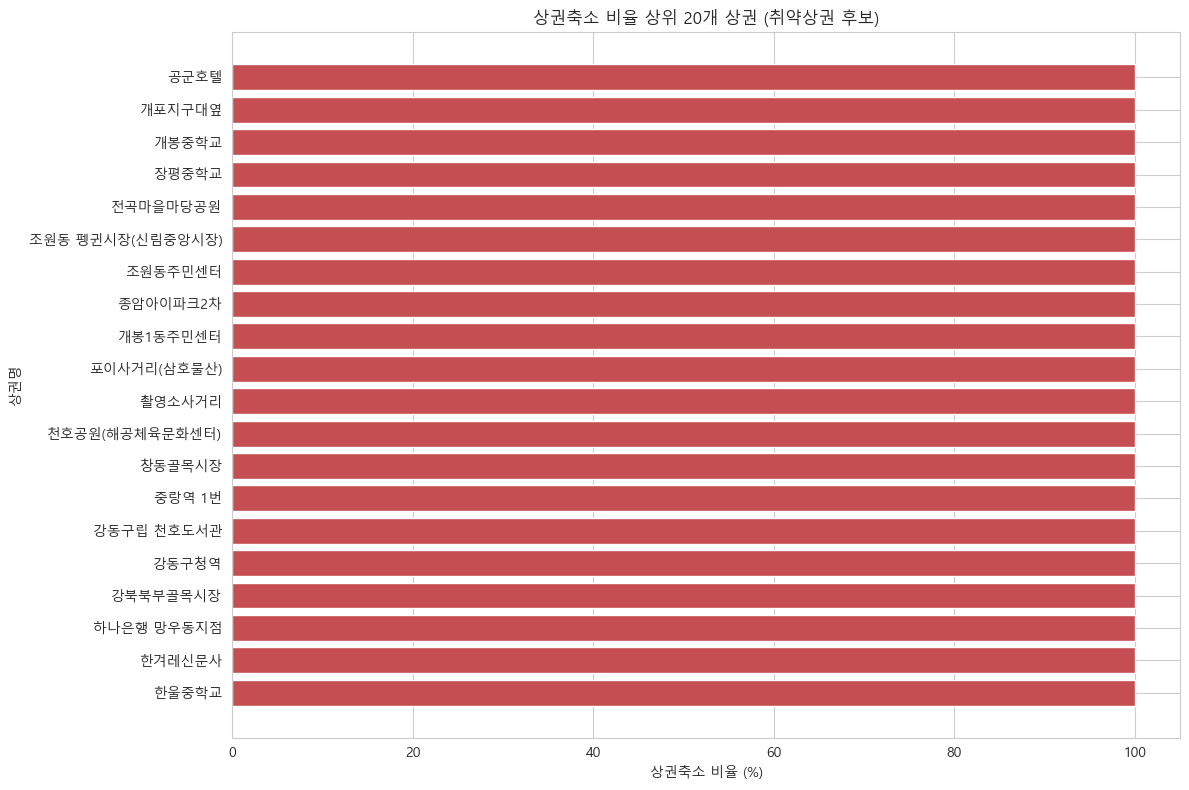

In [ ]:
# 최소 8분기 이상 등장한 상권만 필터링 (2년치 이상)
fig, ax = plt.subplots(figsize=(12, 8))

total = df.groupby('상권_코드_명').size()
축소 = df[df['상권_변화_지표_명'] == '상권축소'].groupby('상권_코드_명').size()
축소_비율 = (축소 / total * 100).dropna()

# 최소 8분기 이상인 상권만
유효상권 = total[total >= 8].index
축소_비율 = 축소_비율[축소_비율.index.isin(유효상권)]
축소_비율 = 축소_비율.sort_values(ascending=False).head(20)

ax.barh(축소_비율.index, 축소_비율.values, color='#C44E52')
ax.set_title('상권축소 비율 상위 20개 상권 (취약상권 후보)')
ax.set_xlabel('상권축소 비율 (%)')
ax.set_ylabel('상권명')
plt.tight_layout()
plt.show()

In [ ]:
# 몇 분기씩 등장하는지 확인
print(total.describe())
print()
print("20분기 이상 상권 수:", len(total[total >= 20]))

count   1,650.00
mean       24.00
std         0.00
min        24.00
25%        24.00
50%        24.00
75%        24.00
max        24.00
dtype: float64

20분기 이상 상권 수: 1650


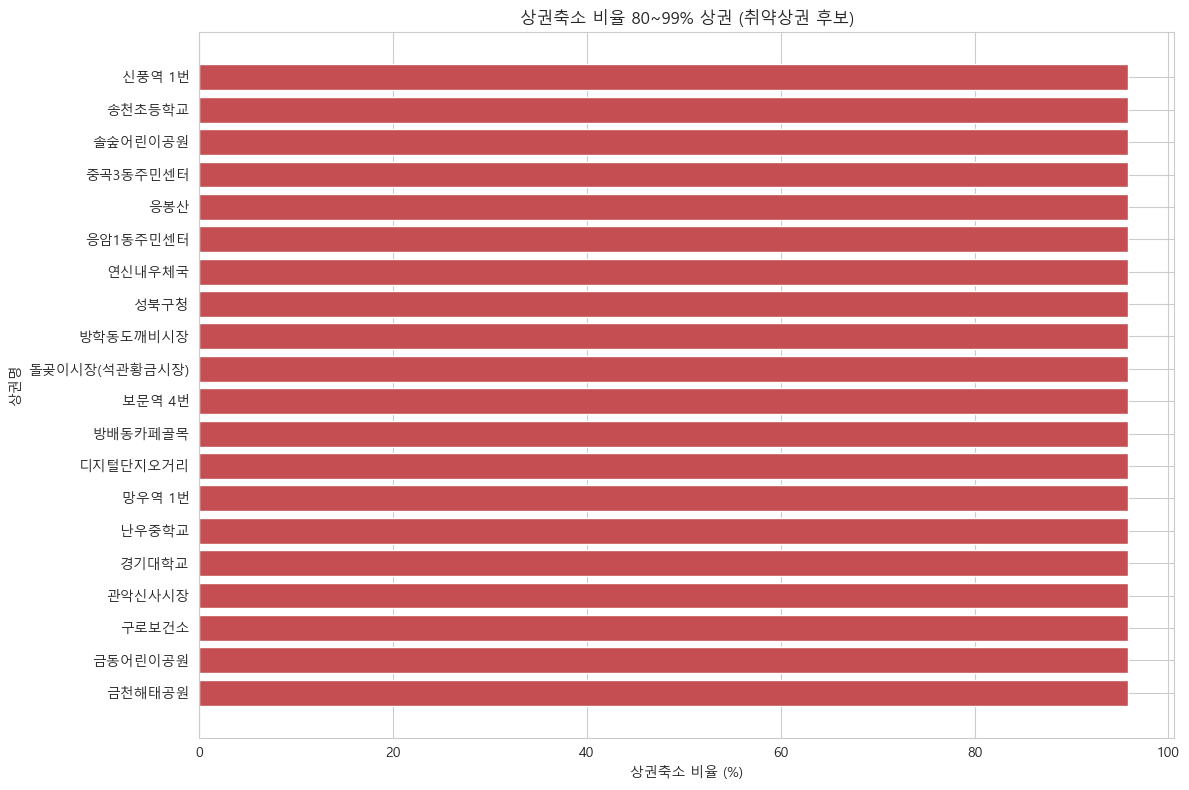

In [ ]:
# 상권 유형 정보 추가해서 취약상권 후보 추출
fig, ax = plt.subplots(figsize=(12, 8))

total = df.groupby('상권_코드_명').size()
축소 = df[df['상권_변화_지표_명'] == '상권축소'].groupby('상권_코드_명').size()
축소_비율 = (축소 / total * 100).dropna()

# 80% 이상 축소된 상권만 (100% 제외)
축소_비율 = 축소_비율[(축소_비율 >= 80) & (축소_비율 < 100)]
축소_비율 = 축소_비율.sort_values(ascending=False).head(20)

ax.barh(축소_비율.index, 축소_비율.values, color='#C44E52')
ax.set_title('상권축소 비율 80~99% 상권 (취약상권 후보)')
ax.set_xlabel('상권축소 비율 (%)')
ax.set_ylabel('상권명')
plt.tight_layout()
plt.show()

In [ ]:
# 축소 비율 분포 확인
print(축소_비율.value_counts().head(10))
print()
print("100% 상권 수:", len(축소_비율[축소_비율 == 100]))
print("80~99% 상권 수:", len(축소_비율[(축소_비율 >= 80) & (축소_비율 < 100)]))
print("50~79% 상권 수:", len(축소_비율[(축소_비율 >= 50) & (축소_비율 < 80)]))

95.83    20
Name: count, dtype: int64

100% 상권 수: 0
80~99% 상권 수: 20
50~79% 상권 수: 0


In [ ]:
# 취약상권 후보 20개 상권 유형 확인
취약상권 = 축소_비율[축소_비율 >= 80].index.tolist()

# 유형 정보 붙이기
취약_df = df[df['상권_코드_명'].isin(취약상권)][['상권_코드_명', '상권_구분_코드_명']].drop_duplicates()
print(취약_df['상권_구분_코드_명'].value_counts())
print()
print(취약_df)

상권_구분_코드_명
골목상권    14
전통시장     3
발달상권     3
Name: count, dtype: int64

            상권_코드_명 상권_구분_코드_명
6650         관악신사시장       전통시장
6779       방학동도깨비시장       전통시장
6799  돌곶이시장(석관황금시장)       전통시장
6998        방배동카페골목       발달상권
7034       디지털단지오거리       발달상권
7089           성북구청       발달상권
7384          난우중학교       골목상권
7446         신풍역 1번       골목상권
7510         금천해태공원       골목상권
7537          구로보건소       골목상권
7716          경기대학교       골목상권
7765         연신내우체국       골목상권
7772       응암1동주민센터       골목상권
7882         송천초등학교       골목상권
7946         보문역 4번       골목상권
7952        솔숲어린이공원       골목상권
7985         망우역 1번       골목상권
8092       중곡3동주민센터       골목상권
8137            응봉산       골목상권
8145        금동어린이공원       골목상권


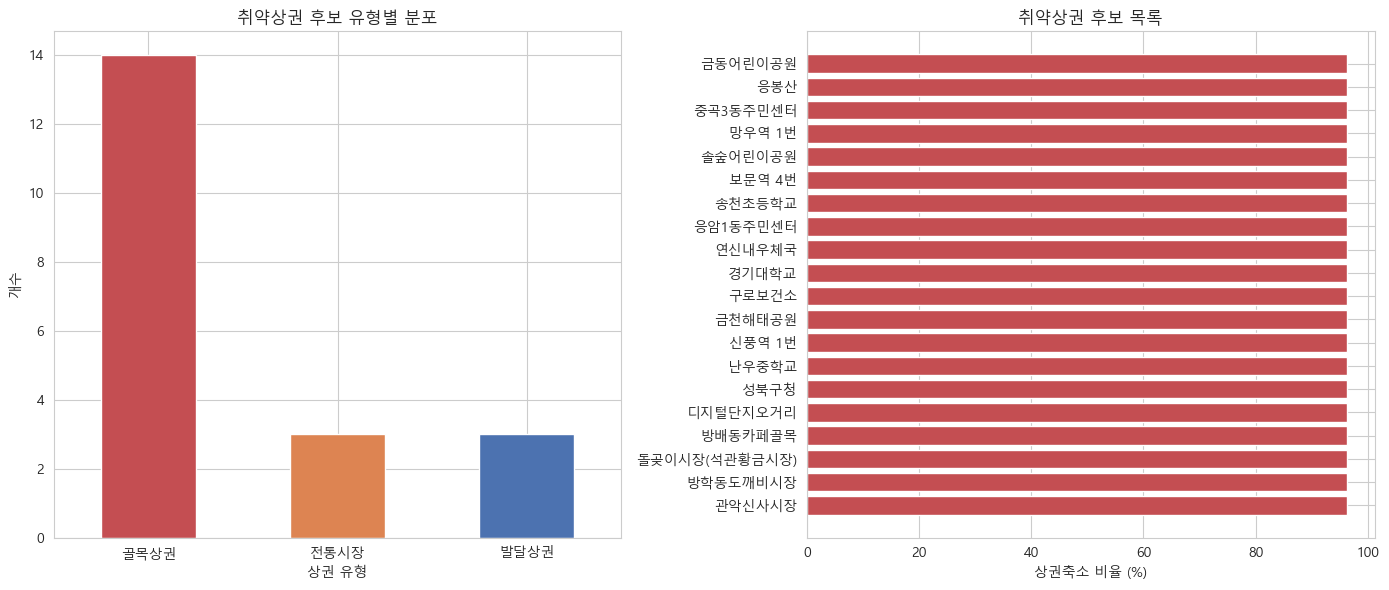

In [ ]:
# 취약상권 후보 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 왼쪽: 유형별 개수
취약_df['상권_구분_코드_명'].value_counts().plot(
    kind='bar', ax=axes[0], color=['#C44E52', '#DD8452', '#4C72B0']
)
axes[0].set_title('취약상권 후보 유형별 분포')
axes[0].set_xlabel('상권 유형')
axes[0].set_ylabel('개수')
axes[0].tick_params(axis='x', rotation=0)

# 오른쪽: 상권명 목록
axes[1].barh(취약_df['상권_코드_명'], [96.4]*len(취약_df), color='#C44E52')
axes[1].set_title('취약상권 후보 목록')
axes[1].set_xlabel('상권축소 비율 (%)')

plt.tight_layout()
plt.show()

## 취약상권 후보 도출 과정
- 상권별 전체 분기 중 상권축소 비율 계산
- 처음 100% 상권 등장 → 데이터 적은 상권이 잡힌 것 → 80~99% 구간으로 필터링
- 결과: 28분기 중 27분기가 상권축소인 상권 20개 (96.4%) 추출

## 취약상권 후보 해석
- 골목상권 11개(55%): 구조적으로 가장 취약한 유형
- 전통시장 5개(25%): 양재시장, 창동골목시장 등 오래된 시장 만성 축소 중
- 발달상권 4개(20%): 유동인구 감소 또는 상권 이동 가능성

## 최종 인사이트
- 서울 상권은 전반적으로 코로나 회복 완료
- 단, 골목상권·일부 전통시장은 코로나와 무관하게 만성적 축소 중

## 나경 EDA - 직장인구/상주인구

In [ ]:
from pathlib import Path
import zipfile
import shutil

# 프로젝트 루트 감지
current = Path.cwd()
project_root = current if (current / 'data').exists() else current.parent

# 경로 설정
target_dir = project_root / 'data' / '06_직장인구'
csv_path = target_dir / '서울시 상권분석서비스(직장인구-상권).csv'

# CSV 없으면 raw/ 에서 zip 찾아서 압축 해제
if not csv_path.exists():
    print('📦 CSV 없음, zip 파일 찾는 중...')
    raw_dir = project_root / 'data' / 'raw'
    
    # 직장인구 관련 zip 찾기
    zip_files = list(raw_dir.glob('*직장인구*.zip'))
    if not zip_files:
        raise FileNotFoundError(f'{raw_dir} 에 직장인구 zip 없음')
    
    zip_path = zip_files[0]
    print(f'  압축 해제: {zip_path.name}')
    target_dir.mkdir(parents=True, exist_ok=True)
    
    # Mac zip의 한글 파일명 문제 해결
    with zipfile.ZipFile(zip_path, 'r') as z:
        for info in z.infolist():
            if info.filename.startswith('__MACOSX'):
                continue
            try:
                filename = info.filename.encode('cp437').decode('utf-8')
            except:
                filename = info.filename
            
            if info.is_dir():
                continue
            
            out_path = target_dir / filename
            out_path.parent.mkdir(parents=True, exist_ok=True)
            with z.open(info) as src, open(out_path, 'wb') as dst:
                shutil.copyfileobj(src, dst)

# CSV 로드
df_직장 = pd.read_csv(csv_path, encoding='cp949')
print(f'✅ 직장인구 로드 완료: {df_직장.shape}')

✅ 직장인구 로드 완료: (45840, 26)


In [ ]:
from pathlib import Path

current = Path.cwd()
project_root = current if (current / 'data').exists() else current.parent

# 06_직장인구 폴더로 수정 ✅
csv_path = project_root / 'data' / '06_직장인구' / '서울시 상권분석서비스(직장인구-상권).csv'

df = pd.read_csv(csv_path, encoding='cp949')
print(f'✅ 로드 완료: {df.shape}')

✅ 로드 완료: (45840, 26)


In [ ]:
# 분석 기간 필터링 (2019~2024)
df_직장 = df_직장[df_직장['기준_년분기_코드'] < 20250]

print("shape:", df_직장.shape)
print("기간:", sorted(df_직장['기준_년분기_코드'].unique()))
print("상권 유형:", df_직장['상권_구분_코드_명'].unique())
df_직장.head()

shape: (39276, 26)
기간: [np.int64(20191), np.int64(20192), np.int64(20193), np.int64(20194), np.int64(20201), np.int64(20202), np.int64(20203), np.int64(20204), np.int64(20211), np.int64(20212), np.int64(20213), np.int64(20214), np.int64(20221), np.int64(20222), np.int64(20223), np.int64(20224), np.int64(20231), np.int64(20232), np.int64(20233), np.int64(20234), np.int64(20241), np.int64(20242), np.int64(20243), np.int64(20244)]
상권 유형: <StringArray>
['관광특구', '전통시장', '발달상권', '골목상권']
Length: 4, dtype: str


,기준_년분기_코드,상권_구분_코드,상권_구분_코드_명,상권_코드,상권_코드_명,총_직장_인구_수,남성_직장_인구_수,여성_직장_인구_수,연령대_10_직장_인구_수,연령대_20_직장_인구_수,연령대_30_직장_인구_수,연령대_40_직장_인구_수,연령대_50_직장_인구_수,연령대_60_이상_직장_인구_수,남성연령대_10_직장_인구_수,남성연령대_20_직장_인구_수,남성연령대_30_직장_인구_수,남성연령대_40_직장_인구_수,남성연령대_50_직장_인구_수,남성연령대_60_이상_직장_인구_수,여성연령대_10_직장_인구_수,여성연령대_20_직장_인구_수,여성연령대_30_직장_인구_수,여성연령대_40_직장_인구_수,여성연령대_50_직장_인구_수,여성연령대_60_이상_직장_인구_수
6564,20244,U,관광특구,3001496,강남 마이스 관광특구,102032,68834,33198,260,20558,30594,27320,18116,5184,128,11046,20220,20142,14200,3098,132,9512,10374,7178,3916,2086
6565,20244,U,관광특구,3001495,잠실 관광특구,137602,81307,56295,247,22732,36053,35461,30321,12788,95,11243,22723,22594,16132,8520,152,11489,13330,12867,14189,4268
6566,20244,U,관광특구,3001494,종로?청계 관광특구,46516,26098,20418,658,9450,13848,12650,7438,2472,234,4072,7232,7590,5236,1734,424,5378,6616,5060,2202,738
6567,20244,U,관광특구,3001493,동대문패션타운 관광특구,33754,16984,16770,259,9770,8679,6878,5414,2754,101,4677,5003,3924,2083,1196,158,5093,3676,2954,3331,1558
6568,20244,U,관광특구,3001492,명동 남대문 북창동 다동 무교동 관광특구,199667,114485,85182,372,40531,66760,51480,31752,8772,83,15500,35220,34082,23643,5957,289,25031,31540,17398,8109,2815


In [ ]:
# 결측치 확인
print("결측치:")
print(df_직장.isnull().sum())
print()

# 분석 기간 확인 (2019Q1~2024Q4 맞는지)
print("기간:", sorted(df_직장['기준_년분기_코드'].unique()))
print()

# 상권 유형 확인 (4개 다 있는지)
print("상권 유형:", df_직장['상권_구분_코드_명'].unique())

결측치:
기준_년분기_코드              0
상권_구분_코드               0
상권_구분_코드_명             0
상권_코드                  0
상권_코드_명                0
총_직장_인구_수              0
남성_직장_인구_수             0
여성_직장_인구_수             0
연령대_10_직장_인구_수         0
연령대_20_직장_인구_수         0
연령대_30_직장_인구_수         0
연령대_40_직장_인구_수         0
연령대_50_직장_인구_수         0
연령대_60_이상_직장_인구_수      0
남성연령대_10_직장_인구_수       0
남성연령대_20_직장_인구_수       0
남성연령대_30_직장_인구_수       0
남성연령대_40_직장_인구_수       0
남성연령대_50_직장_인구_수       0
남성연령대_60_이상_직장_인구_수    0
여성연령대_10_직장_인구_수       0
여성연령대_20_직장_인구_수       0
여성연령대_30_직장_인구_수       0
여성연령대_40_직장_인구_수       0
여성연령대_50_직장_인구_수       0
여성연령대_60_이상_직장_인구_수    0
dtype: int64

기간: [np.int64(20191), np.int64(20192), np.int64(20193), np.int64(20194), np.int64(20201), np.int64(20202), np.int64(20203), np.int64(20204), np.int64(20211), np.int64(20212), np.int64(20213), np.int64(20214), np.int64(20221), np.int64(20222), np.int64(20223), np.int64(20224), np.int64(20231), np.int64(20232), np.int64(20233), np.

## 기본 정보
- 행: 39,276개 / 컬럼: 26개
- 기간: 2019Q1 ~ 2024Q4 
- 상권 유형: 관광특구/전통시장/발달상권/골목상권 4개 
- 결측치: 없음 

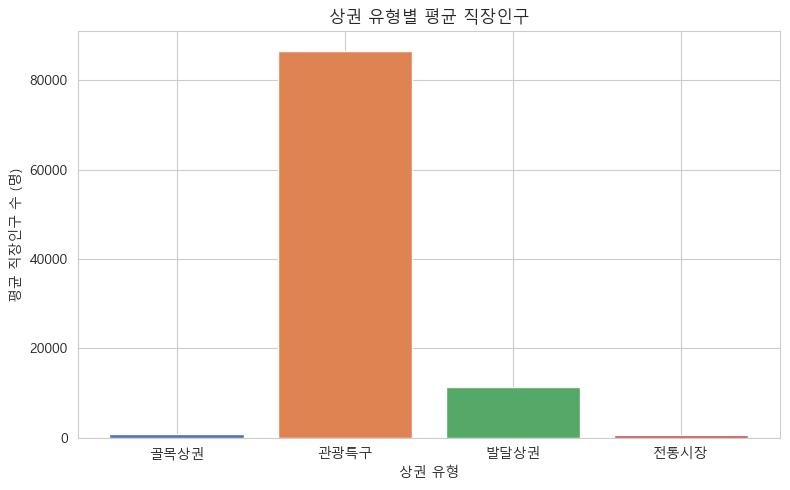

In [ ]:
# 상권 유형별 총 직장인구 평균 계산
평균_직장 = df_직장.groupby('상권_구분_코드_명')['총_직장_인구_수'].mean().reset_index()

# 막대 그래프
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(평균_직장['상권_구분_코드_명'], 평균_직장['총_직장_인구_수'],
       color=['#4C72B0', '#DD8452', '#55A868', '#C44E52'])

ax.set_title('상권 유형별 평균 직장인구')
ax.set_xlabel('상권 유형')
ax.set_ylabel('평균 직장인구 수 (명)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 상권 유형별 평균 직장인구
- 관광특구: 약 87,000명으로 압도적 1위
- 발달상권: 약 11,000명으로 2위
- 골목상권/전통시장: 매우 낮음
- 관광특구는 대규모 업무지구와 겹치는 경우가 많아 직장인구 집중

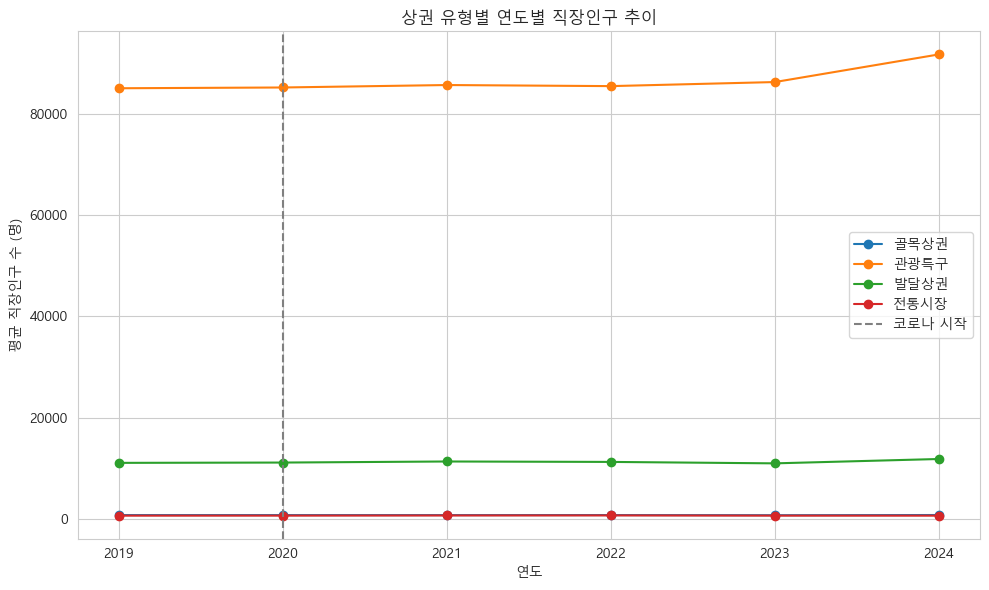

In [ ]:
# 연도 컬럼 추가
df_직장['연도'] = df_직장['기준_년분기_코드'].astype(str).str[:4].astype(int)

# 상권 유형별 연도별 평균 직장인구
연도별 = df_직장.groupby(['연도', '상권_구분_코드_명'])['총_직장_인구_수'].mean().reset_index()

# 꺾은선 그래프
fig, ax = plt.subplots(figsize=(10, 6))
for 유형 in 연도별['상권_구분_코드_명'].unique():
    df_유형 = 연도별[연도별['상권_구분_코드_명'] == 유형]
    ax.plot(df_유형['연도'], df_유형['총_직장_인구_수'], marker='o', label=유형)

# 코로나 시점 표시
ax.axvline(x=2020, color='gray', linestyle='--', label='코로나 시작')

ax.set_title('상권 유형별 연도별 직장인구 추이')
ax.set_xlabel('연도')
ax.set_ylabel('평균 직장인구 수 (명)')
ax.legend()
plt.tight_layout()
plt.show()

## 상권 유형별 연도별 직장인구 추이
- 관광특구: 코로나 영향 없이 꾸준히 증가 → 2024년 최고치
- 발달상권: 전체 기간 안정적으로 유지
- 골목상권/전통시장: 직장인구 매우 적음 → 주거/소비 중심 상권
- 전반적으로 직장인구는 코로나 영향을 거의 받지 않음

In [ ]:
from pathlib import Path
import zipfile, shutil

current = Path.cwd()
project_root = current if (current / 'data').exists() else current.parent

# 경로
target_dir = project_root / 'data' / '07_상주인구'
csv_path = target_dir / '서울시 상권분석서비스(상주인구-상권).csv'

# CSV 없으면 raw에서 zip 찾아서 자동 압축 해제
if not csv_path.exists():
    print('📦 CSV 없음, zip 찾는 중...')
    raw_dir = project_root / 'data' / 'raw'
    
    zip_files = list(raw_dir.glob('*상주인구*.zip'))
    if not zip_files:
        raise FileNotFoundError(f'{raw_dir} 에 상주인구 zip 없음')
    
    zip_path = zip_files[0]
    print(f'  압축 해제: {zip_path.name}')
    target_dir.mkdir(parents=True, exist_ok=True)
    
    with zipfile.ZipFile(zip_path, 'r') as z:
        for info in z.infolist():
            if info.filename.startswith('__MACOSX'):
                continue
            try:
                filename = info.filename.encode('cp437').decode('utf-8')
            except:
                filename = info.filename
            
            if info.is_dir():
                continue
            
            out_path = target_dir / filename
            out_path.parent.mkdir(parents=True, exist_ok=True)
            with z.open(info) as src, open(out_path, 'wb') as dst:
                shutil.copyfileobj(src, dst)
    print(f'  ✅ 완료')

# CSV 로드
df_상주 = pd.read_csv(csv_path, encoding='cp949')
print(f'✅ 상주인구 로드: {df_상주.shape}')

✅ 상주인구 로드: (40812, 29)


In [ ]:
from pathlib import Path

current = Path.cwd()
project_root = current if (current / 'data').exists() else current.parent

# 상주인구 파일 경로
csv_path = project_root / 'data' / '07_상주인구' / '서울시 상권분석서비스(상주인구-상권).csv'

# 상주인구 데이터 불러오기
df_상주 = pd.read_csv(csv_path, encoding='cp949')
print(f'✅ 상주인구 로드 완료: {df_상주.shape}')

✅ 상주인구 로드 완료: (40812, 29)


In [ ]:
# 분석 기간 필터링 (2019~2024)
df_상주 = df_상주[df_상주['기준_년분기_코드'] < 20250]

print("shape:", df_상주.shape)
print("기간:", sorted(df_상주['기준_년분기_코드'].unique()))
print("상권 유형:", df_상주['상권_구분_코드_명'].unique())
print()
print("결측치:")
print(df_상주.isnull().sum())

shape: (34280, 29)
기간: [np.int64(20194), np.int64(20201), np.int64(20202), np.int64(20203), np.int64(20204), np.int64(20211), np.int64(20212), np.int64(20213), np.int64(20214), np.int64(20221), np.int64(20222), np.int64(20223), np.int64(20224), np.int64(20231), np.int64(20232), np.int64(20233), np.int64(20234), np.int64(20241), np.int64(20242), np.int64(20243), np.int64(20244)]
상권 유형: <StringArray>
['관광특구', '전통시장', '발달상권', '골목상권']
Length: 4, dtype: str

결측치:
기준_년분기_코드             0
상권_구분_코드              0
상권_구분_코드_명            0
상권_코드                 0
상권_코드_명               0
총_상주인구_수              0
남성_상주인구_수             0
여성_상주인구_수             0
연령대_10_상주인구_수         0
연령대_20_상주인구_수         0
연령대_30_상주인구_수         0
연령대_40_상주인구_수         0
연령대_50_상주인구_수         0
연령대_60_이상_상주인구_수      0
남성연령대_10_상주인구_수       0
남성연령대_20_상주인구_수       0
남성연령대_30_상주인구_수       0
남성연령대_40_상주인구_수       0
남성연령대_50_상주인구_수       0
남성연령대_60_이상_상주인구_수    0
여성연령대_10_상주인구_수       0
여성연령대_20_상주인구_수       0
여성연령대_30_

## 상주인구 기본 정보
- 행: 34,280개 / 컬럼: 29개
- 기간: 2019Q4 ~ 2024Q4 (직장인구와 달리 2019Q4부터 시작)
- 상권 유형: 4개 
- 결측치: 없음 

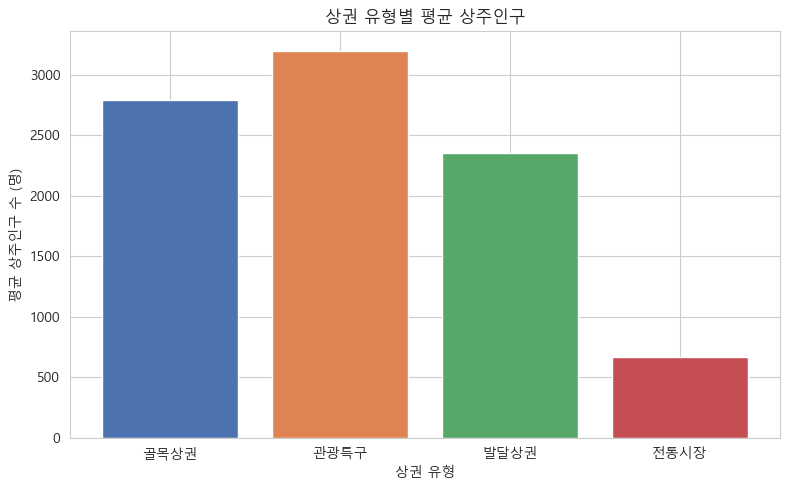

In [ ]:
# 상권 유형별 총 상주인구 평균 계산
평균_상주 = df_상주.groupby('상권_구분_코드_명')['총_상주인구_수'].mean().reset_index()

# 막대 그래프
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(평균_상주['상권_구분_코드_명'], 평균_상주['총_상주인구_수'],
       color=['#4C72B0', '#DD8452', '#55A868', '#C44E52'])

ax.set_title('상권 유형별 평균 상주인구')
ax.set_xlabel('상권 유형')
ax.set_ylabel('평균 상주인구 수 (명)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 상권 유형별 평균 상주인구
- 관광특구: 약 3,200명으로 1위
- 골목상권: 약 2,800명으로 2위 → 주거 밀집 지역에 분포
- 발달상권: 약 2,350명
- 전통시장: 약 670명으로 가장 낮음
- 직장인구와 달리 유형 간 격차가 크지 않음

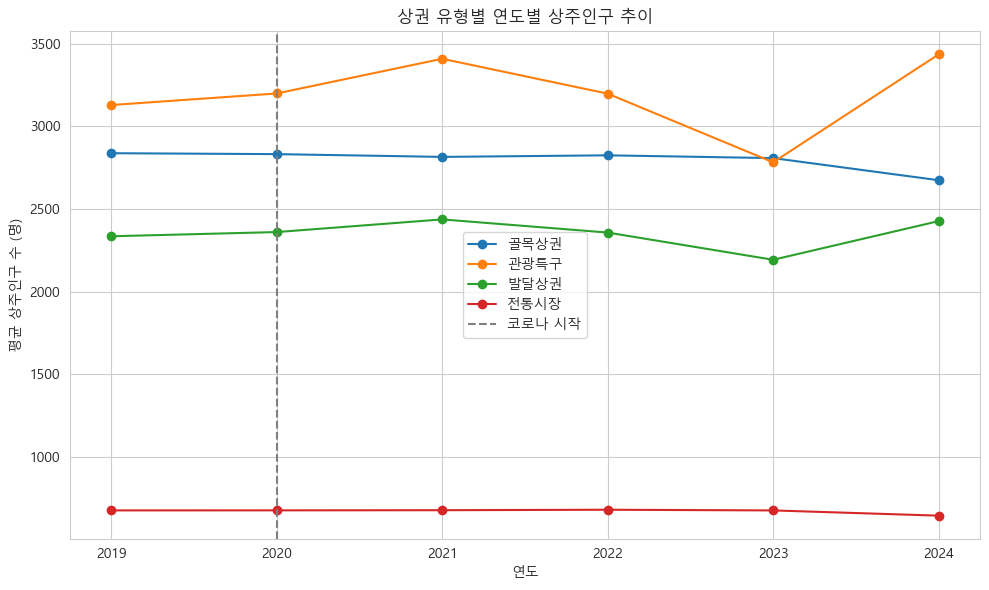

In [ ]:
# 연도 컬럼 추가
df_상주['연도'] = df_상주['기준_년분기_코드'].astype(str).str[:4].astype(int)

# 상권 유형별 연도별 평균 상주인구
연도별_상주 = df_상주.groupby(['연도', '상권_구분_코드_명'])['총_상주인구_수'].mean().reset_index()

# 꺾은선 그래프
fig, ax = plt.subplots(figsize=(10, 6))
for 유형 in 연도별_상주['상권_구분_코드_명'].unique():
    df_유형 = 연도별_상주[연도별_상주['상권_구분_코드_명'] == 유형]
    ax.plot(df_유형['연도'], df_유형['총_상주인구_수'], marker='o', label=유형)

# 코로나 시점 표시
ax.axvline(x=2020, color='gray', linestyle='--', label='코로나 시작')

ax.set_title('상권 유형별 연도별 상주인구 추이')
ax.set_xlabel('연도')
ax.set_ylabel('평균 상주인구 수 (명)')
ax.legend()
plt.tight_layout()
plt.show()

## 상권 유형별 연도별 상주인구 추이
- 관광특구: 등락 있으나 전반적으로 가장 높음
- 골목상권: 전체 기간 안정적 유지 → 주거 기반 탄탄
- 발달상권: 2023년 하락 후 2024년 회복
- 전통시장: 전체 기간 가장 낮고 변화 거의 없음
- 상주인구는 직장인구와 달리 코로나 영향 거의 없음

### 정연 EDA - 길단위 인구

In [ ]:
from pathlib import Path

current = Path.cwd()
project_root = current if (current / 'data').exists() else current.parent

csv_path = project_root / 'data' / 'extracted' /'서울시 상권분석서비스(길단위인구-상권)\서울시 상권분석서비스(길단위인구-상권).csv'

df = pd.read_csv(csv_path, encoding='cp949')
print(f'✅ 로드 완료: {df.shape}')

✅ 로드 완료: (46184, 27)


In [ ]:
df.dtypes

기준_년분기_코드           int64
상권_구분_코드              str
상권_구분_코드_명            str
상권_코드               int64
상권_코드_명               str
총_유동인구_수            int64
남성_유동인구_수           int64
여성_유동인구_수           int64
연령대_10_유동인구_수       int64
연령대_20_유동인구_수       int64
연령대_30_유동인구_수       int64
연령대_40_유동인구_수       int64
연령대_50_유동인구_수       int64
연령대_60_이상_유동인구_수    int64
시간대_00_06_유동인구_수    int64
시간대_06_11_유동인구_수    int64
시간대_11_14_유동인구_수    int64
시간대_14_17_유동인구_수    int64
시간대_17_21_유동인구_수    int64
시간대_21_24_유동인구_수    int64
월요일_유동인구_수          int64
화요일_유동인구_수          int64
수요일_유동인구_수          int64
목요일_유동인구_수          int64
금요일_유동인구_수          int64
토요일_유동인구_수          int64
일요일_유동인구_수          int64
dtype: object

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 46184 entries, 0 to 46183
Data columns (total 27 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   기준_년분기_코드         46184 non-null  int64
 1   상권_구분_코드          46184 non-null  str  
 2   상권_구분_코드_명        46184 non-null  str  
 3   상권_코드             46184 non-null  int64
 4   상권_코드_명           46184 non-null  str  
 5   총_유동인구_수          46184 non-null  int64
 6   남성_유동인구_수         46184 non-null  int64
 7   여성_유동인구_수         46184 non-null  int64
 8   연령대_10_유동인구_수     46184 non-null  int64
 9   연령대_20_유동인구_수     46184 non-null  int64
 10  연령대_30_유동인구_수     46184 non-null  int64
 11  연령대_40_유동인구_수     46184 non-null  int64
 12  연령대_50_유동인구_수     46184 non-null  int64
 13  연령대_60_이상_유동인구_수  46184 non-null  int64
 14  시간대_00_06_유동인구_수  46184 non-null  int64
 15  시간대_06_11_유동인구_수  46184 non-null  int64
 16  시간대_11_14_유동인구_수  46184 non-null  int64
 17  시간대_14_17_유동인구_수  46184 non-null  int64
 1

In [ ]:
# 결측치 확인
print(df.isnull().sum())

기준_년분기_코드           0
상권_구분_코드            0
상권_구분_코드_명          0
상권_코드               0
상권_코드_명             0
총_유동인구_수            0
남성_유동인구_수           0
여성_유동인구_수           0
연령대_10_유동인구_수       0
연령대_20_유동인구_수       0
연령대_30_유동인구_수       0
연령대_40_유동인구_수       0
연령대_50_유동인구_수       0
연령대_60_이상_유동인구_수    0
시간대_00_06_유동인구_수    0
시간대_06_11_유동인구_수    0
시간대_11_14_유동인구_수    0
시간대_14_17_유동인구_수    0
시간대_17_21_유동인구_수    0
시간대_21_24_유동인구_수    0
월요일_유동인구_수          0
화요일_유동인구_수          0
수요일_유동인구_수          0
목요일_유동인구_수          0
금요일_유동인구_수          0
토요일_유동인구_수          0
일요일_유동인구_수          0
dtype: int64


In [ ]:
# 기초 통계량 확인 (평균, 최소, 최대값 등)
df.describe()

,기준_년분기_코드,상권_코드,총_유동인구_수,남성_유동인구_수,여성_유동인구_수,연령대_10_유동인구_수,연령대_20_유동인구_수,연령대_30_유동인구_수,연령대_40_유동인구_수,연령대_50_유동인구_수,연령대_60_이상_유동인구_수,시간대_00_06_유동인구_수,시간대_06_11_유동인구_수,시간대_11_14_유동인구_수,시간대_14_17_유동인구_수,시간대_17_21_유동인구_수,시간대_21_24_유동인구_수,월요일_유동인구_수,화요일_유동인구_수,수요일_유동인구_수,목요일_유동인구_수,금요일_유동인구_수,토요일_유동인구_수,일요일_유동인구_수
count,"46,184.00","46,184.00","46,184.00","46,184.00","46,184.00","46,184.00","46,184.00","46,184.00","46,184.00","46,184.00","46,184.00","46,184.00","46,184.00","46,184.00","46,184.00","46,184.00","46,184.00","46,184.00","46,184.00","46,184.00","46,184.00","46,184.00","46,184.00","46,184.00"
mean,"20,222.49","3,115,223.38","836,435.79","398,217.24","438,218.57","106,679.15","147,630.81","146,839.64","134,404.89","121,909.63","178,971.75","200,374.63","170,402.76","108,092.36","109,209.73","145,008.32","103,348.07","120,010.81","120,640.73","120,898.47","120,835.68","120,677.41","117,590.46","115,782.31"
std,20.03,"10,320.12","896,371.99","434,798.04","465,166.74","114,134.05","209,880.99","179,613.67","150,382.66","128,682.39","186,231.89","212,417.16","179,106.39","133,019.04","136,552.30","166,788.31","109,195.30","129,620.15","131,494.21","131,898.14","132,053.80","132,387.51","125,076.27","120,244.64"
min,"20,191.00","3,001,491.00",4.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,"20,203.00","3,110,407.00","231,351.00","110,057.50","120,051.75","26,270.75","32,704.50","36,877.25","37,534.75","34,369.25","48,765.75","49,749.75","47,291.50","29,618.50","29,830.00","39,916.50","26,949.75","33,033.50","33,151.25","33,313.75","33,309.75","33,263.25","32,051.00","31,469.25"
50%,"20,222.00","3,110,819.00","571,569.50","270,961.50","299,698.00","71,390.00","84,134.00","93,885.50","90,884.50","83,716.00","123,743.00","132,641.00","117,618.50","72,448.50","72,625.50","97,024.00","69,949.50","82,302.00","82,471.00","82,602.50","82,433.00","82,356.50","80,346.50","79,236.50"
75%,"20,241.00","3,120,142.00","1,150,718.50","545,755.00","601,728.25","148,928.00","184,469.00","188,870.00","181,329.50","169,566.00","250,572.25","282,057.50","235,820.50","141,654.50","142,078.00","195,463.00","142,694.00","165,537.25","165,937.50","165,942.50","165,847.50","165,378.00","161,864.00","159,671.25"
max,"20,254.00","3,130,327.00","10,936,954.00","5,904,661.00","5,075,322.00","2,025,696.00","3,487,417.00","2,147,251.00","1,926,666.00","1,896,481.00","2,789,894.00","2,637,438.00","1,947,241.00","2,251,342.00","2,437,343.00","2,319,158.00","1,092,221.00","1,636,435.00","1,723,636.00","1,730,759.00","1,783,350.00","1,802,017.00","1,425,047.00","1,338,150.00"


# 총 유동인구: 데이터 스케일 차이가 너무 크다 → 로그 변환
# 연령대: 모든 연령대에 0이 존재 
# 요일: max값 - 토,일 100% → 특정 요일에 유동인구가 거의 몰린 상권이 존재

In [ ]:
import numpy as np
df['log_유동인구'] = np.log1p(df['총_유동인구_수'])
df['log_유동인구']

0       11.61
1       15.26
2       15.94
3       15.01
4       15.80
         ... 
46179   11.77
46180   13.11
46181   13.47
46182   13.20
46183   11.96
Name: log_유동인구, Length: 46184, dtype: float64

<Axes: xlabel='log_유동인구', ylabel='Count'>

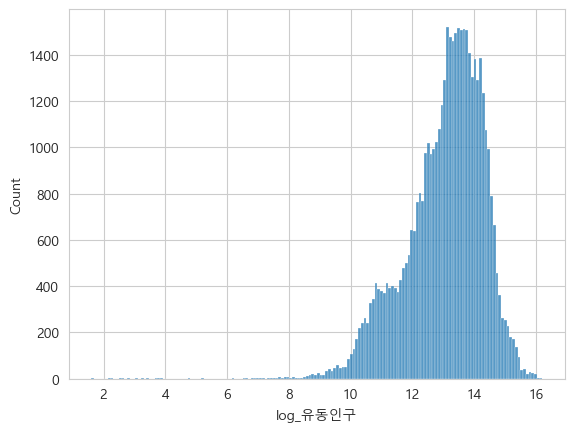

In [ ]:
sns.histplot(df['log_유동인구'])

## 유동 인구 로그 변환 후 확인
## 원래 총_유동인구_수는: 작은 값 많고 큰 값 일부 (관광특구 같은 애들)
## 로그 변환 후 확인 -> 종 모양에 가까움을 확인 

## 상권 유형별 성별 유동인구 비율
### 여성이 남성보다 구매가 많음을 확인 

In [ ]:
# 성별 비율
df['남성_비율'] = df['남성_유동인구_수'] / df['총_유동인구_수'] * 100
df['여성_비율'] = df['여성_유동인구_수'] / df['총_유동인구_수'] * 100

# 연령대 비율 (6개 컬럼)
age_cols = ['연령대_10','연령대_20','연령대_30','연령대_40','연령대_50','연령대_60_이상']
raw_cols = [f'{c}_유동인구_수' for c in age_cols]

for c, r in zip(age_cols, raw_cols):
    df[f'{c}_비율'] = df[r] / df['총_유동인구_수'] * 100

In [ ]:
# 상권 유형별 성별 비율 평균
gender_by_type = df.groupby('상권_구분_코드_명')[['남성_비율','여성_비율']].mean()

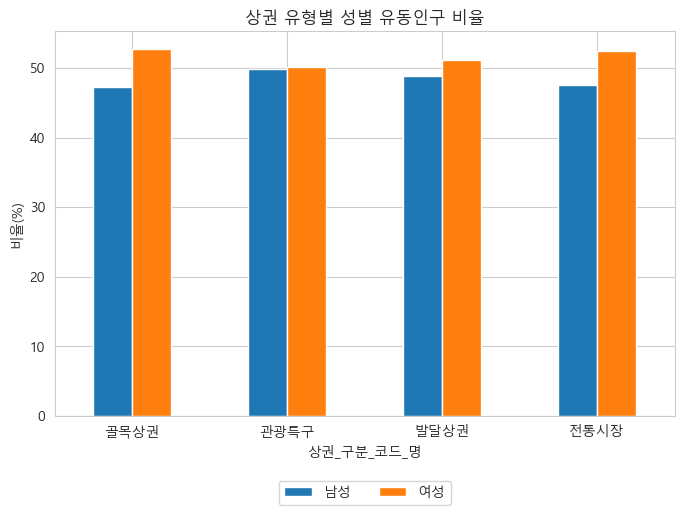

In [ ]:
df['남성_비율'] = df['남성_유동인구_수'] / df['총_유동인구_수'] * 100
df['여성_비율'] = df['여성_유동인구_수'] / df['총_유동인구_수'] * 100

age_cols = ['연령대_10','연령대_20','연령대_30','연령대_40','연령대_50','연령대_60_이상']

for col in age_cols:
    df[f'{col}_비율'] = df[f'{col}_유동인구_수'] / df['총_유동인구_수'] * 100

gender_by_type = df.groupby('상권_구분_코드_명')[['남성_비율','여성_비율']].mean()

import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

gender_by_type.plot(kind='bar', figsize=(8,5))

plt.title('상권 유형별 성별 유동인구 비율')
plt.ylabel('비율(%)')
plt.xticks(rotation=0)
plt.legend(['남성','여성'],
           loc='upper center',
           bbox_to_anchor=(0.5, -0.15),
           ncol=2)
plt.show()

### 상권 유형별 분기별 평균 유동인구 추세

In [ ]:
# 20211 → 연도 2021, 분기 1
df['연도'] = df['기준_년분기_코드'] // 10
df['분기'] = df['기준_년분기_코드'] % 10

# 시각화·정렬용 문자열 레이블
df['년분기'] = df['연도'].astype(str) + '-Q' + df['분기'].astype(str)

# pandas Period로 변환 (시계열 연산에 유리)
df['period'] = pd.PeriodIndex(
    df['연도'].astype(str) + 'Q' + df['분기'].astype(str), freq='Q'
)

# 정렬 확인
print(sorted(df['년분기'].unique()))
# ['2021-Q1', '2021-Q2', ..., '2023-Q4']

['2019-Q1', '2019-Q2', '2019-Q3', '2019-Q4', '2020-Q1', '2020-Q2', '2020-Q3', '2020-Q4', '2021-Q1', '2021-Q2', '2021-Q3', '2021-Q4', '2022-Q1', '2022-Q2', '2022-Q3', '2022-Q4', '2023-Q1', '2023-Q2', '2023-Q3', '2023-Q4', '2024-Q1', '2024-Q2', '2024-Q3', '2024-Q4', '2025-Q1', '2025-Q2', '2025-Q3', '2025-Q4']


In [ ]:
df['연도'] = df['기준_년분기_코드'] // 10
df['분기'] = df['기준_년분기_코드'] % 10

df['년분기'] = df['연도'].astype(str) + '-Q' + df['분기'].astype(str)

ts = df.groupby(['년분기', '상권_구분_코드_명'])['총_유동인구_수'].mean().reset_index()

<Figure size 1200x600 with 0 Axes>

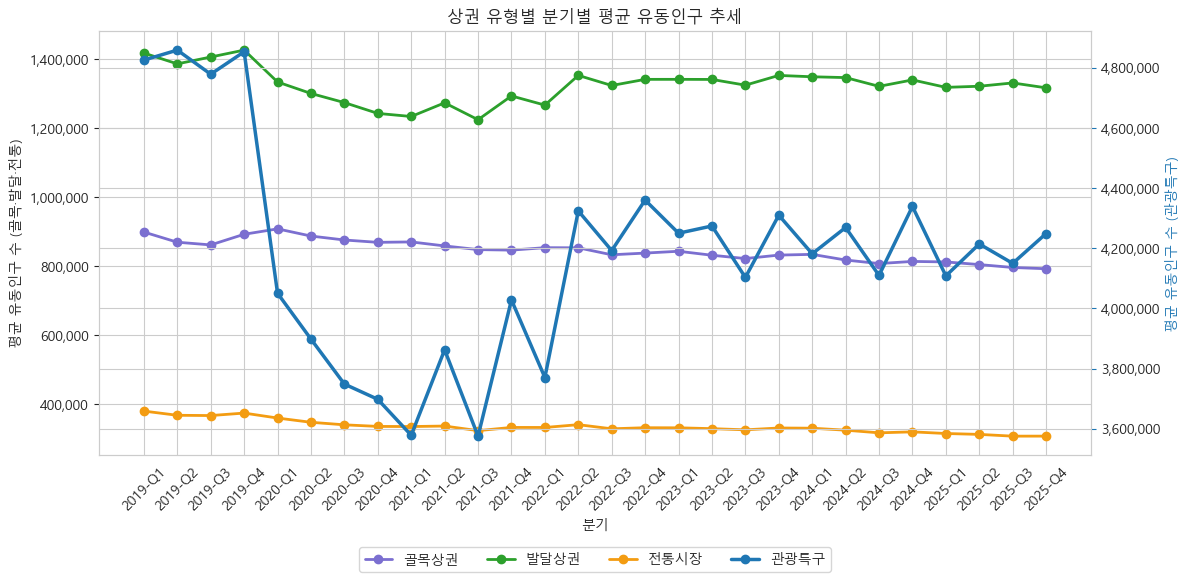

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(12,6))
fig, ax1 = plt.subplots(figsize=(12,6))
ax2 = ax1.twinx()  # 오른쪽 축

# 색상 (가독성 좋게)
색상 = {
    '골목상권': '#7b6fd0',
    '발달상권': '#2ca02c',
    '전통시장': '#f39c12',
    '관광특구': '#1f77b4'
}

for name, grp in ts.groupby('상권_구분_코드_명'):
    
    if name == '관광특구':
        ax2.plot(grp['년분기'], grp['총_유동인구_수'],
                 marker='o', linewidth=2.5,
                 color=색상[name], label=name)
    else:
        ax1.plot(grp['년분기'], grp['총_유동인구_수'],
                 marker='o', linewidth=2,
                 color=색상[name], label=name)

# 축 설정
ax1.set_xlabel('분기')
ax1.set_ylabel('평균 유동인구 수 (골목·발달·전통)')
ax2.set_ylabel('평균 유동인구 수 (관광특구)', color=색상['관광특구'])

# x축 회전
ax1.tick_params(axis='x', rotation=45)

# y축 색상 맞추기
ax2.tick_params(axis='y', color=색상['관광특구'])

# 숫자 포맷 (천 단위 콤마)
import matplotlib.ticker as mticker
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# 범례 합치기
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(lines1 + lines2, labels1 + labels2,
           loc='upper center',
           bbox_to_anchor=(0.5, -0.2),
           ncol=4)

plt.title('상권 유형별 분기별 평균 유동인구 추세')

plt.tight_layout()
plt.show()

# 상권 유형별 시간대 유동인구 비율

# 골목상권 — 심야형
# 25.5%로 전체 상권 중 1위 → 심야 유흥·음식점 업종이 구조적으로 많다

# 관광특구
# 외국인 관광객은 특정 시간에 몰리지 않고 낮 내내 분산 방문

# 발달상권 - 직장인 루트
# 출근길 방문과 퇴근 후

# 전통시장 - 새벽·오전형
# 00~06시(21.7%)가 골목상권 다음으로 높음 
# → 새벽 도매·납품 상인의 이동 인구가 반영

In [ ]:
time_cols_raw = [
    '시간대_00_06_유동인구_수', '시간대_06_11_유동인구_수',
    '시간대_11_14_유동인구_수', '시간대_14_17_유동인구_수',
    '시간대_17_21_유동인구_수', '시간대_21_24_유동인구_수'
]
time_labels = ['00~06시', '06~11시', '11~14시', '14~17시', '17~21시', '21~24시']

# 비율 컬럼 생성
for col, label in zip(time_cols_raw, time_labels):
    df[f'{label}_비율'] = df[col] / df['총_유동인구_수'] * 100

time_ratio_cols = [f'{l}_비율' for l in time_labels]

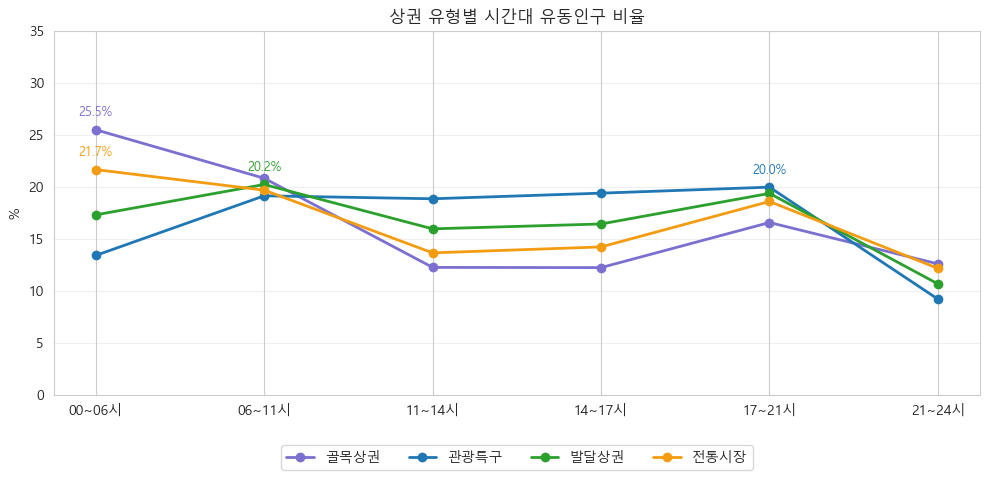

In [ ]:
time_by_type = df.groupby('상권_구분_코드_명')[time_ratio_cols].mean()
time_by_type.columns = time_labels


fig, ax = plt.subplots(figsize=(10, 5))

for type_name, row in time_by_type.iterrows():
    ax.plot(time_labels, row.values,
            marker='o', markersize=6, linewidth=2,
            color=색상[type_name], label=type_name)

    # 피크 시간대 강조
    peak_idx = row.values.argmax()
    ax.annotate(f'{row.values[peak_idx]:.1f}%',
                xy=(peak_idx, row.values[peak_idx]),
                xytext=(0, 10), textcoords='offset points',
                ha='center', fontsize=9, color=색상[type_name])

ax.set_title('상권 유형별 시간대 유동인구 비율')
ax.set_ylabel('%')
ax.set_ylim(0, 35)
ax.grid(axis='y', alpha=0.3)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.12),
          ncol=4, framealpha=0.9, edgecolor='lightgray', fontsize=10)
plt.tight_layout()
plt.subplots_adjust(bottom=0.2)
plt.show()

### 유동인구 Top 20 상권

In [ ]:
# 상권 간 비교 분석
# Top N 상권 랭킹
import matplotlib.font_manager as fm

# 한글 폰트 설정 (환경에 맞게 조정)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

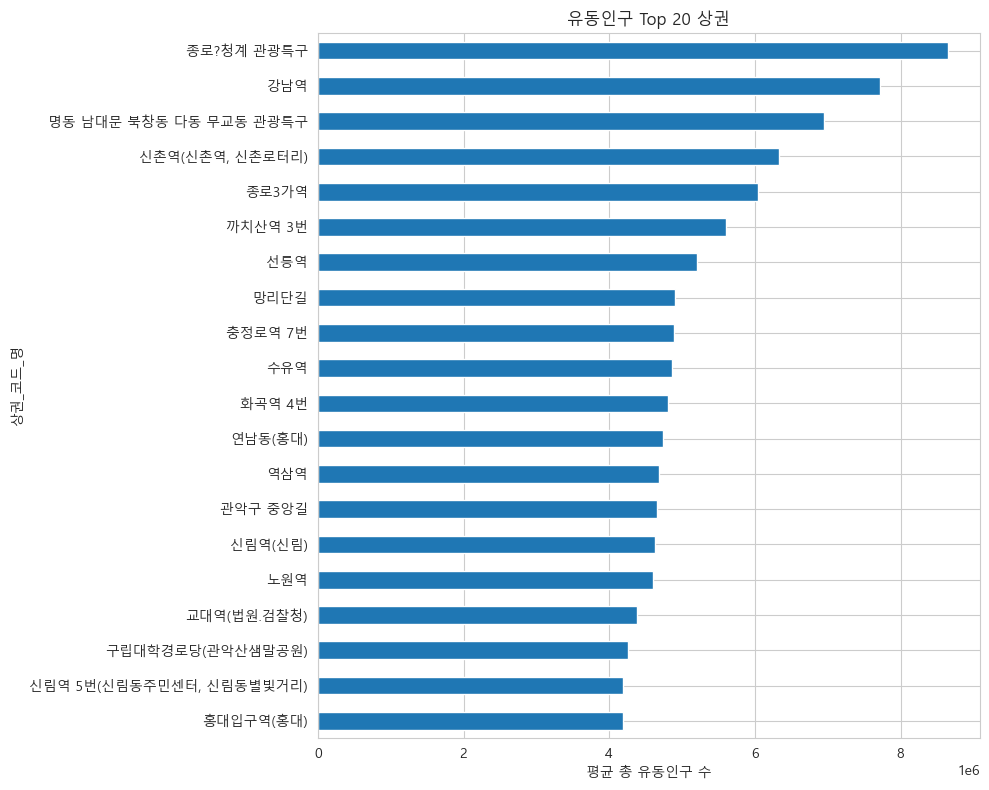

In [ ]:
# 상권별 평균 유동인구 (분기 여러 개 있으므로 평균 사용)
top_n = (df.groupby('상권_코드_명')['총_유동인구_수']
           .mean()
           .sort_values(ascending=False)
           .head(20))

top_n.sort_values().plot(kind='barh', figsize=(10, 8))
plt.xlabel('평균 총 유동인구 수')
plt.title('유동인구 Top 20 상권')
plt.tight_layout()
plt.show()

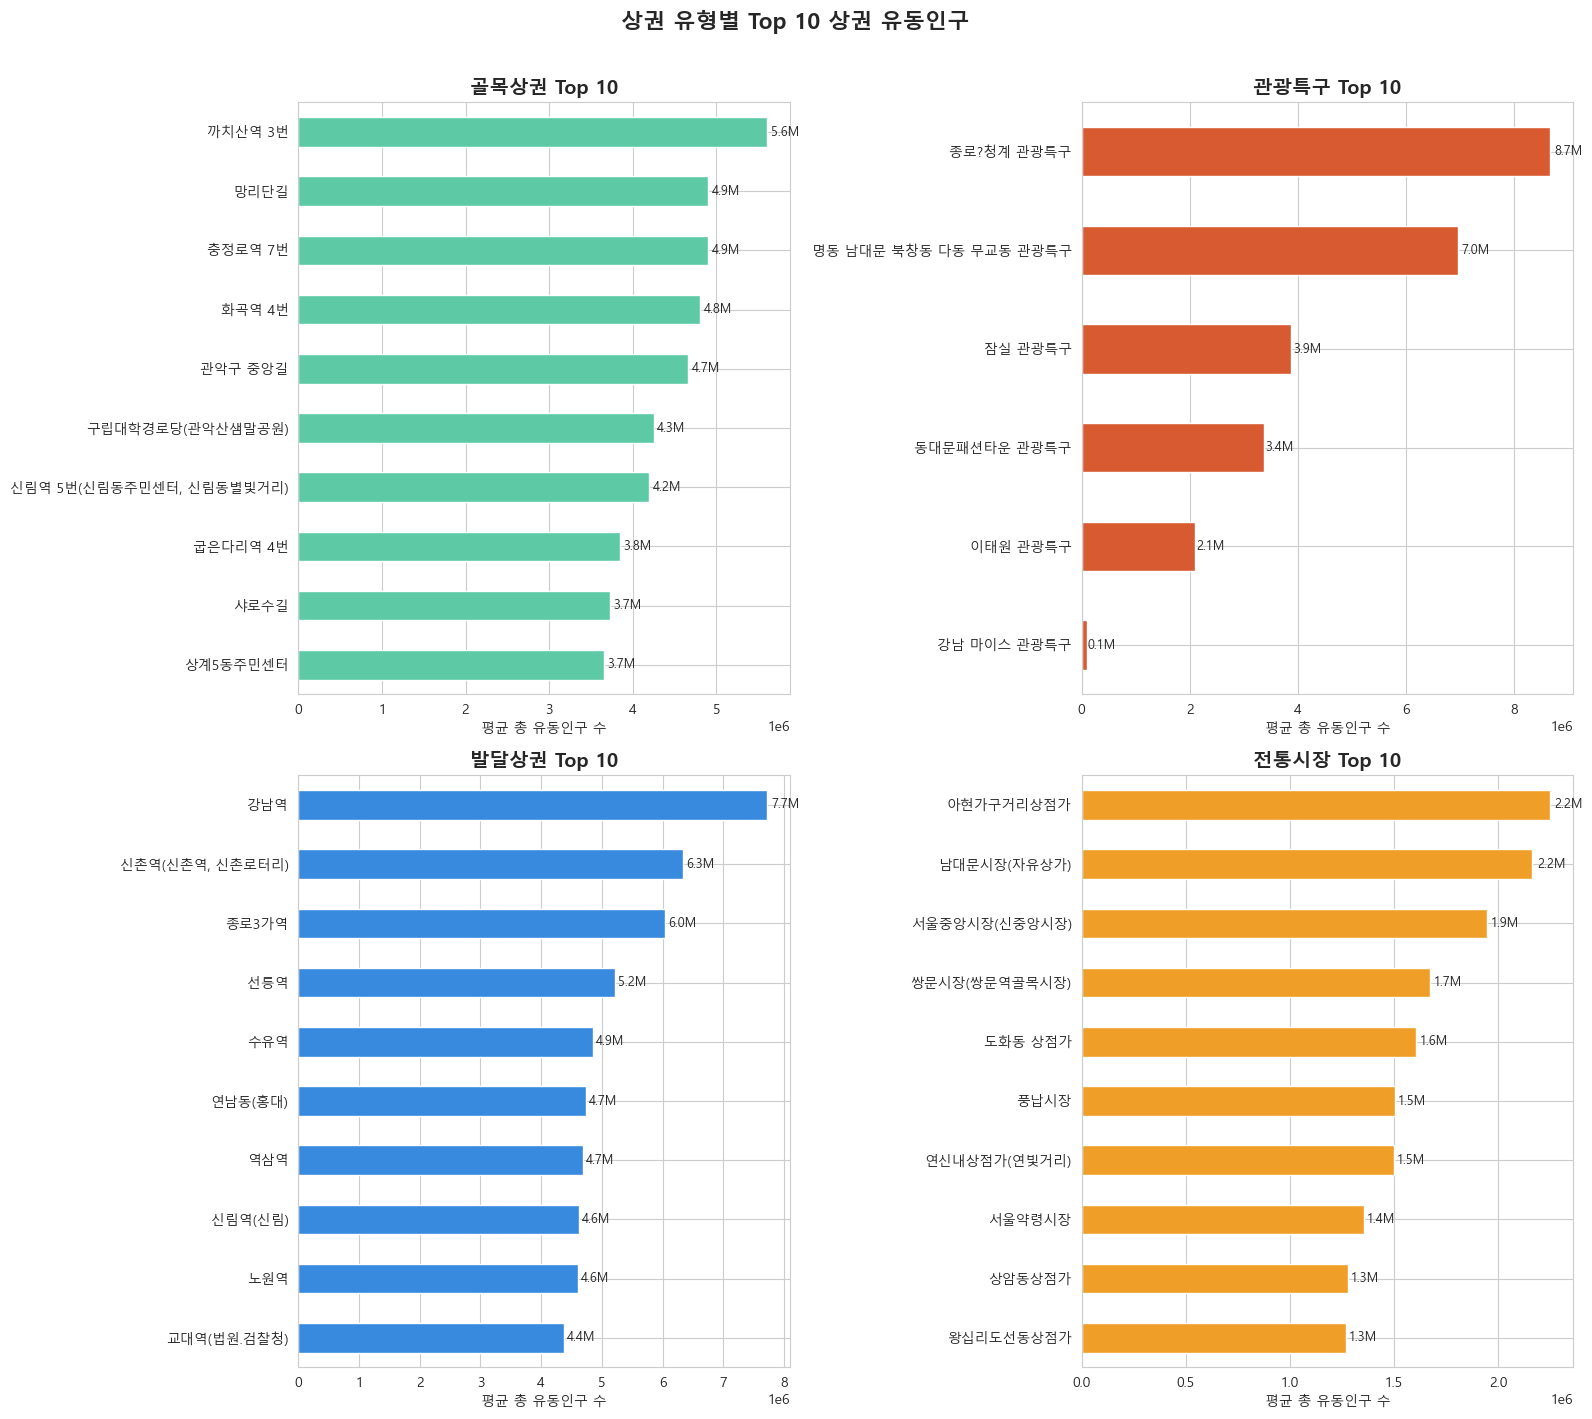

In [ ]:
types = df['상권_구분_코드_명'].unique()

color_dict = {
    '골목상권':  '#5DCAA5',
    '발달상권':  '#378ADD',
    '관광특구':  '#D85A30',
    '전통시장':  '#EF9F27'
}

fig, axes = plt.subplots(2, 2, figsize=(16, 14))
axes = axes.flatten()

for i, t in enumerate(sorted(types)):
    top = (df[df['상권_구분_코드_명'] == t]
             .groupby('상권_코드_명')['총_유동인구_수']
             .mean()
             .sort_values(ascending=False)
             .head(10)
             .sort_values())  # barh는 아래가 1위라 오름차순

    color = color_dict.get(t, '#888')
    top.plot(kind='barh', ax=axes[i], color=color)
    axes[i].set_title(f'{t} Top 10', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('평균 총 유동인구 수')
    axes[i].set_ylabel('')

        # 막대 끝에 값 표시
    for bar in axes[i].patches:
        axes[i].text(
            bar.get_width() * 1.01,
            bar.get_y() + bar.get_height() / 2,
            f'{bar.get_width()/1e6:.1f}M',
            va='center', fontsize=9
        )

plt.suptitle('상권 유형별 Top 10 상권 유동인구', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 상권 유형별 x 요일별 유동인구 비율

In [ ]:
day_cols_raw = [
    '월요일_유동인구_수', '화요일_유동인구_수', '수요일_유동인구_수',
    '목요일_유동인구_수', '금요일_유동인구_수', '토요일_유동인구_수', '일요일_유동인구_수'
]
day_labels = ['월', '화', '수', '목', '금', '토', '일']

# 요일별 비율 생성
for col, label in zip(day_cols_raw, day_labels):
    df[f'{label}요일_비율'] = df[col] / df['총_유동인구_수'] * 100

day_ratio_cols = [f'{l}요일_비율' for l in day_labels]

# 평일·주말 파생 컬럼
df['평일_평균_비율'] = df[[f'{l}요일_비율' for l in ['월','화','수','목','금']]].mean(axis=1)
df['주말_평균_비율'] = df[[f'{l}요일_비율' for l in ['토','일']]].mean(axis=1)
df['주말_집중도']   = df['주말_평균_비율'] - df['평일_평균_비율'] 

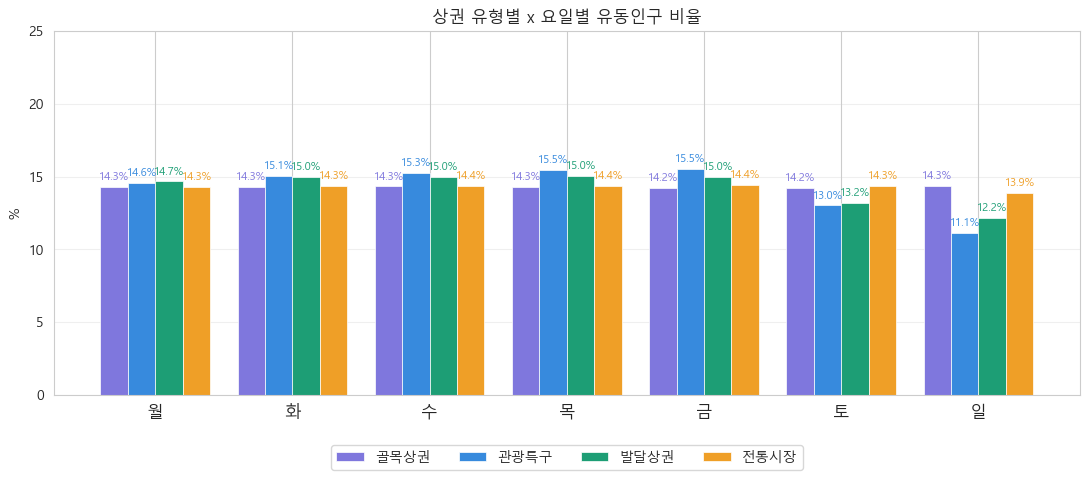

In [ ]:
day_by_type = df.groupby('상권_구분_코드_명')[day_ratio_cols].mean()
day_by_type.columns = day_labels

색상 = {
    '골목상권': '#7F77DD', '관광특구': '#378ADD',
    '발달상권': '#1D9E75', '전통시장': '#EF9F27'
}

x = np.arange(len(day_labels))
width = 0.2
fig, ax = plt.subplots(figsize=(11, 5))

for i, (type_name, row) in enumerate(day_by_type.iterrows()):
    bars = ax.bar(x + i * width, row.values, width,
                  label=type_name, color=색상[type_name],
                  edgecolor='white', linewidth=0.5)
    ax.bar_label(bars, fmt='%.1f%%', padding=3, fontsize=8,
                 color=색상[type_name])

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(day_labels, fontsize=12)
ax.set_ylim(0, 25)
ax.set_title('상권 유형별 x 요일별 유동인구 비율')
ax.set_ylabel('%')
ax.grid(axis='y', alpha=0.3)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.12),
          ncol=4, framealpha=0.9, edgecolor='lightgray', fontsize=10)
plt.tight_layout()
plt.subplots_adjust(bottom=0.2)
plt.show()

# 코로나 시기 비교 

### 관광특구 - 가장 크게 떨어지고, 가장 많이 회복
### 엔데믹 구간에서 회복했지만 코로나 후에 감소하는 현상 발견 → . 외국인 관광객 회복이 기대에 못 미쳤거나, 사회적 이슈나로 인해 이미지 타격

### 골목상권
### 골목상권 자체의 구조적 감소(꼭 코로나의 문제는 아닌걸로 보임) → 온라인 소비 전환, 대형몰 집중화 영향

### 발달상권
### 엔데믹 이후 회복이 거의 stop
### → 직장인 유동인구가 줄어든 영향

### 전통시장
### 전반적으로 비중이 가장 작음

In [ ]:
# 코로나 구간 매핑 함수
def covid_label(code):
    if 20191 <= code <= 20194:
        return '①코로나 전'
    elif 20201 <= code <= 20223:
        return '②코로나 집중'
    elif 20224 <= code <= 20232:
        return '③엔데믹'
    elif 20233 <= code <= 20254:
        return '④코로나 후'
    else:
        return '기타'

df['코로나_구간'] = df['기준_년분기_코드'].apply(covid_label)

# 구간 순서 고정 (그래프 정렬용)
covid_order = ['①코로나 전', '②코로나 집중', '③엔데믹', '④코로나 후']
df['코로나_구간'] = pd.Categorical(df['코로나_구간'],
                                    categories=covid_order, ordered=True)

# 구간 × 상권 유형별 평균 유동인구
covid_by_type = (df.groupby(['코로나_구간', '상권_구분_코드_명'])['총_유동인구_수']
                    .mean()
                    .unstack('상권_구분_코드_명'))

print(covid_by_type.map(lambda x: f'{x:,.0f}'))

상권_구분_코드_명     골목상권       관광특구       발달상권     전통시장
코로나_구간                                            
①코로나 전      881,415  4,829,419  1,409,800  373,186
②코로나 집중     864,782  3,884,007  1,284,339  338,439
③엔데믹        838,435  4,294,808  1,342,099  331,732
④코로나 후      814,147  4,203,373  1,332,888  320,004


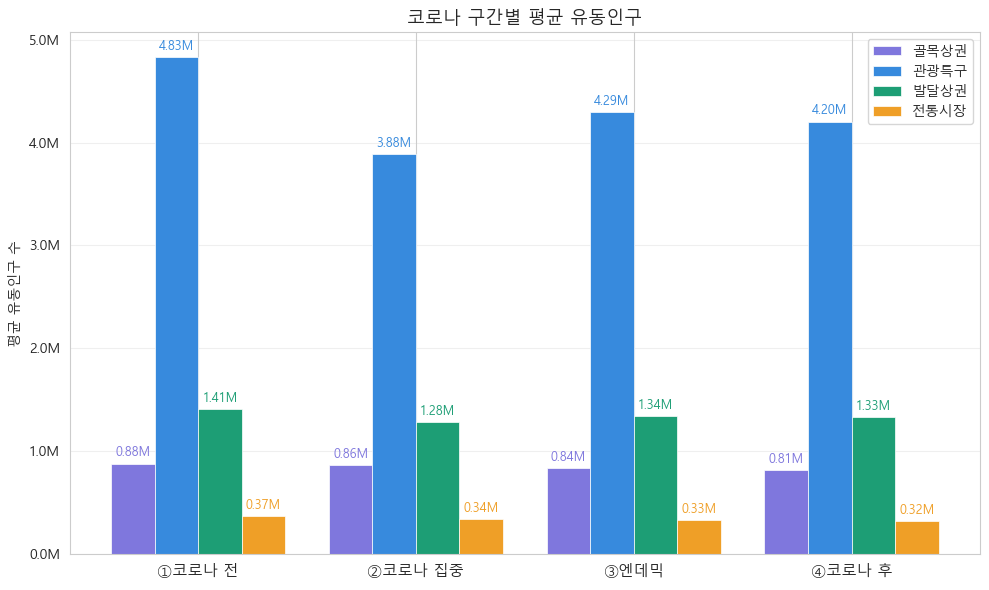

In [ ]:
색상 = {
    '골목상권': '#7F77DD', '관광특구': '#378ADD',
    '발달상권': '#1D9E75', '전통시장': '#EF9F27'
}

fig, ax = plt.subplots(figsize=(10, 6))  # subplot 제거, 단일 ax

x = np.arange(len(covid_order))
width = 0.2

for i, type_name in enumerate(covid_by_type.columns):
    offset = (i - len(covid_by_type.columns) / 2 + 0.5) * width
    bars = ax.bar(x + offset,
                  covid_by_type[type_name].values,
                  width, label=type_name,
                  color=색상[type_name],
                  edgecolor='white', linewidth=0.5)
    ax.bar_label(bars,
                 labels=[f'{v/1e6:.2f}M' for v in covid_by_type[type_name].values],
                 padding=3, fontsize=9, color=색상[type_name])

ax.set_xticks(x)
ax.set_xticklabels(covid_order, fontsize=11)
ax.set_title('코로나 구간별 평균 유동인구', fontsize=13)
ax.set_ylabel('평균 유동인구 수')
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
ax.grid(axis='y', alpha=0.3)
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

### 소희 -상품분석서비스(점포_상권)

In [40]:
from pathlib import Path
import zipfile
import shutil

# 경로 설정
current = Path.cwd()
project_root = current if (current / 'data').exists() else current.parent
target_dir = project_root / 'data' / 'extracted' / '상권분석서비스(점포_상권)'
zip_path = project_root / 'data' / 'raw' / '상권분석서비스(점포_상권).zip'

# 1. zip 한 번만 풀기 (이미 풀려있으면 스킵)
if not target_dir.exists() or not any(target_dir.iterdir()):
    print(f'📦 압축 해제 중: {zip_path.name}')
    target_dir.mkdir(parents=True, exist_ok=True)
    
    with zipfile.ZipFile(zip_path, 'r') as z:
        for info in z.infolist():
            if info.filename.startswith('__MACOSX'):
                continue
            try:
                filename = info.filename.encode('cp437').decode('utf-8')
            except:
                filename = info.filename
            if info.is_dir():
                continue
            out_path = target_dir / filename
            out_path.parent.mkdir(parents=True, exist_ok=True)
            with z.open(info) as src, open(out_path, 'wb') as dst:
                shutil.copyfileobj(src, dst)
    print('  ✅ 완료')

# 2. 풀린 폴더 안의 모든 CSV 자동 통합
import glob
csv_files = sorted(target_dir.glob('*.csv'))
print(f'\n📂 CSV 파일 {len(csv_files)}개 발견:')
for f in csv_files:
    print(f'  {f.name}')

# 3. 모두 로드해서 통합 (인코딩 자동 시도)
dfs = []
for csv_path in csv_files:
    try:
        df = pd.read_csv(csv_path, encoding='cp949', low_memory=False)
    except UnicodeDecodeError:
        df = pd.read_csv(csv_path, encoding='utf-8', low_memory=False)
    dfs.append(df)
    print(f'✅ {csv_path.name}: {df.shape}')

df_전체 = pd.concat(dfs, ignore_index=True)
print(f'\n📊 전체 데이터: {df_전체.shape}')


📂 CSV 파일 6개 발견:
  서울시 상권분석서비스(점포-상권)_2024년.csv
  서울시_상권분석서비스(점포-상권)_2019년.csv
  서울시_상권분석서비스(점포-상권)_2020년.csv
  서울시_상권분석서비스(점포-상권)_2021년.csv
  서울시_상권분석서비스(점포-상권)_2022년.csv
  서울시_상권분석서비스(점포-상권)_2023년.csv
✅ 서울시 상권분석서비스(점포-상권)_2024년.csv: (306889, 14)
✅ 서울시_상권분석서비스(점포-상권)_2019년.csv: (297369, 14)
✅ 서울시_상권분석서비스(점포-상권)_2020년.csv: (310459, 14)
✅ 서울시_상권분석서비스(점포-상권)_2021년.csv: (303880, 14)
✅ 서울시_상권분석서비스(점포-상권)_2022년.csv: (305587, 14)
✅ 서울시_상권분석서비스(점포-상권)_2023년.csv: (307741, 14)

📊 전체 데이터: (1831925, 14)


In [39]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

plt.rcParams['font.family'] = 'AppleGothic'  # Mac 한글 폰트
plt.rcParams['axes.unicode_minus'] = False    # 마이너스 기호 깨짐 방지

* 전년도 불러오기 = df_전체
* 연도별 불러오기 = dfs[2019]

In [ ]:
# 점포수 null 값 확인
df_전체[['점포_수','유사_업종_점포_수','개업_율','폐업_률','폐업_점포_수','프랜차이즈_점포_수']].isnull().sum()

점포_수          0
유사_업종_점포_수    0
개업_율          0
폐업_률          0
폐업_점포_수       0
프랜차이즈_점포_수    0
dtype: int64

In [ ]:
#음수값 있는지 확인
(df_전체[['점포_수','유사_업종_점포_수','개업_율','폐업_률','폐업_점포_수','프랜차이즈_점포_수']]<0).sum()

점포_수          0
유사_업종_점포_수    0
개업_율          0
폐업_률          0
폐업_점포_수       0
프랜차이즈_점포_수    0
dtype: int64

In [ ]:
#2019~2024 null 값 없음.
df_전체.info()

<class 'pandas.DataFrame'>
RangeIndex: 1831925 entries, 0 to 1831924
Data columns (total 14 columns):
 #   Column       Dtype
---  ------       -----
 0   기준_년분기_코드    int64
 1   상권_구분_코드     str  
 2   상권_구분_코드_명   str  
 3   상권_코드        int64
 4   상권_코드_명      str  
 5   서비스_업종_코드    str  
 6   서비스_업종_코드_명  str  
 7   점포_수         int64
 8   유사_업종_점포_수   int64
 9   개업_율         int64
 10  개업_점포_수      int64
 11  폐업_률         int64
 12  폐업_점포_수      int64
 13  프랜차이즈_점포_수   int64
dtypes: int64(9), str(5)
memory usage: 195.7 MB


# 상권 규모 분석

* 연도별 상권별 점포수 (트렌드)

In [52]:
#연도별 평균 점포수

# 연도 컬럼 추가 (앞 4자리만 추출)
df_전체['연도'] = df_전체['기준_년분기_코드'].astype(str).str[:4].astype(int)

# 연도 + 상권구분별 평균 점포수
result= df_전체.groupby(['연도','상권_구분_코드_명'])['점포_수'].mean().reset_index()

# 피벗
pivot_store = result.pivot(index='상권_구분_코드_명', columns='연도', values='점포_수')
print(pivot_store)

연도          2019  2020  2021  2022  2023  2024
상권_구분_코드_명                                    
골목상권        3.25  3.22  3.37  3.44  3.49  3.48
관광특구       65.55 65.40 64.79 65.16 64.97 63.21
발달상권       11.80 11.99 12.47 12.79 13.06 13.03
전통시장        5.40  5.25  5.44  5.48  5.46  5.39


findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Fon

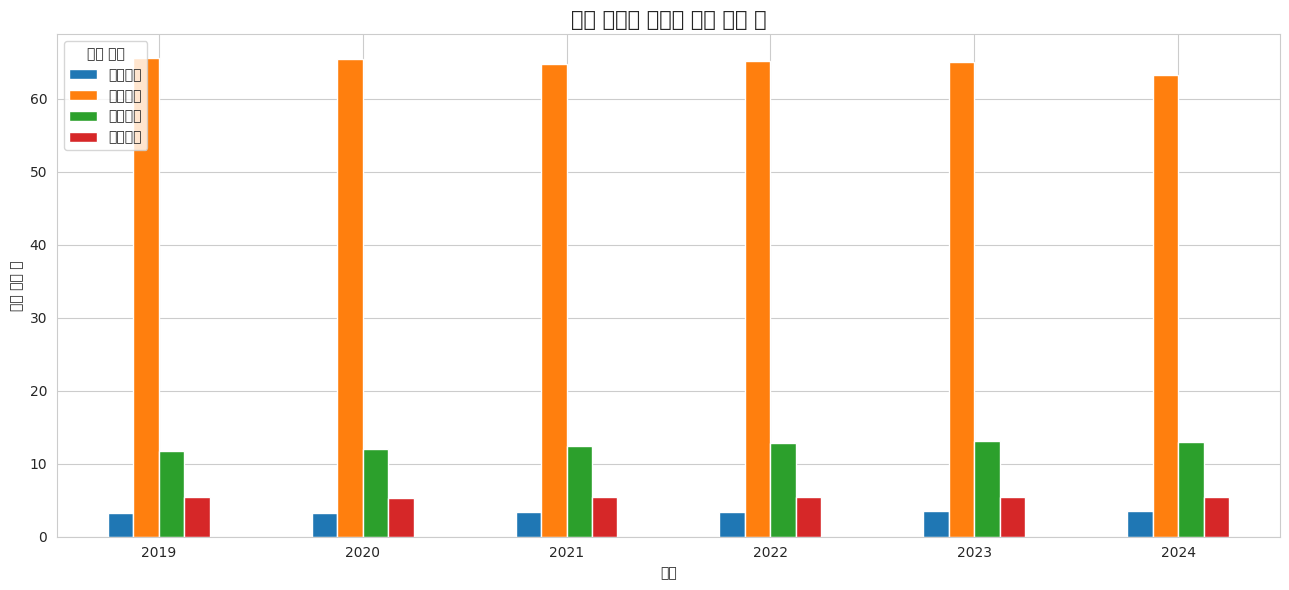

In [ ]:
pivot_store.T.plot(kind='bar', figsize=(13, 6), edgecolor='white')

plt.title('상권 구분별 연도별 평균 점포 수', fontsize=15)
plt.xlabel('연도')
plt.ylabel('평균 점포 수')
plt.xticks(rotation=0)
plt.legend(title='상권 구분', loc='upper left')
plt.tight_layout()
plt.show()

# 상권별 폐업률 추이

In [53]:
# 연도별 폐업수 합계 / 전체 점포수 합계로 폐업률 직접 계산
연도별 = df_전체.groupby(['연도', '상권_구분_코드_명']).agg(
    폐업수=('폐업_점포_수', 'sum'),
    전체점포수=('점포_수', 'sum')
).reset_index()

연도별['폐업률'] = (연도별['폐업수'] / 연도별['전체점포수'] * 100).round(2)

# 피벗
pivot_close = 연도별.pivot(index='상권_구분_코드_명', columns='연도', values='폐업률')
print(pivot_close)


연도          2019  2020  2021  2022  2023  2024
상권_구분_코드_명                                    
골목상권        3.14  2.91  2.97  2.75  3.27  3.43
관광특구        2.47  2.72  2.51  1.95  2.26  2.32
발달상권        2.87  2.83  2.65  2.43  2.78  2.85
전통시장        2.89  2.80  2.51  2.32  2.66  2.84


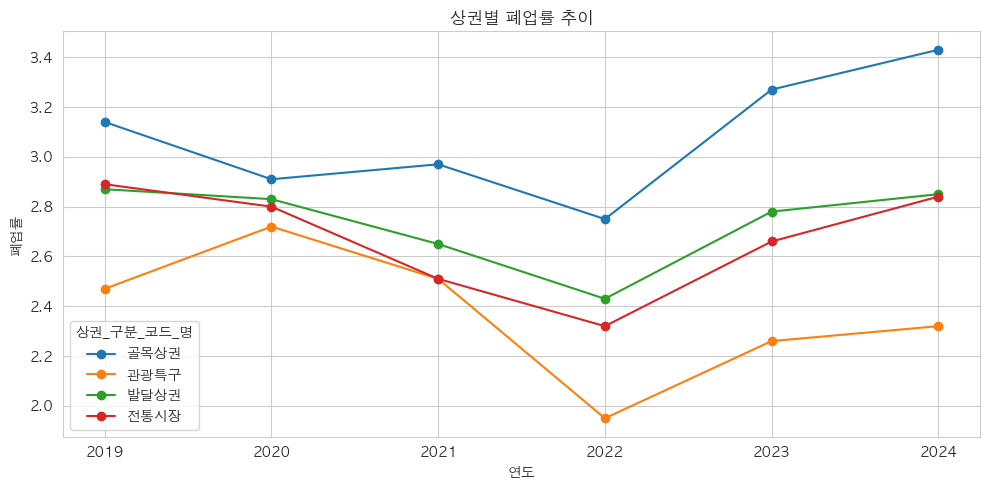

In [54]:
pivot_close.T.plot(kind='line', figsize=(10, 5), marker='o')
plt.title('상권별 폐업률 추이')
plt.ylabel('폐업률')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# 상권별 개업률 추이

In [55]:
# 연도별 개업수 합계 / 전체 점포수 합계로 개업율 직접 계산
연도별 = df_전체.groupby(['연도', '상권_구분_코드_명']).agg(
    개업수=('개업_점포_수', 'sum'),
    전체점포수=('점포_수', 'sum')
).reset_index()

연도별['개업율'] = (연도별['개업수'] / 연도별['전체점포수'] * 100).round(2)

# 피벗
pivot_open = 연도별.pivot(index='상권_구분_코드_명', columns='연도', values='개업율')
print(pivot_open)

연도          2019  2020  2021  2022  2023  2024
상권_구분_코드_명                                    
골목상권        4.25  3.94  3.58  3.48  3.78  2.74
관광특구        3.53  2.61  2.21  2.26  2.28  1.24
발달상권        4.23  3.64  3.31  3.16  3.31  2.43
전통시장        3.54  3.15  2.72  2.52  2.66  2.14


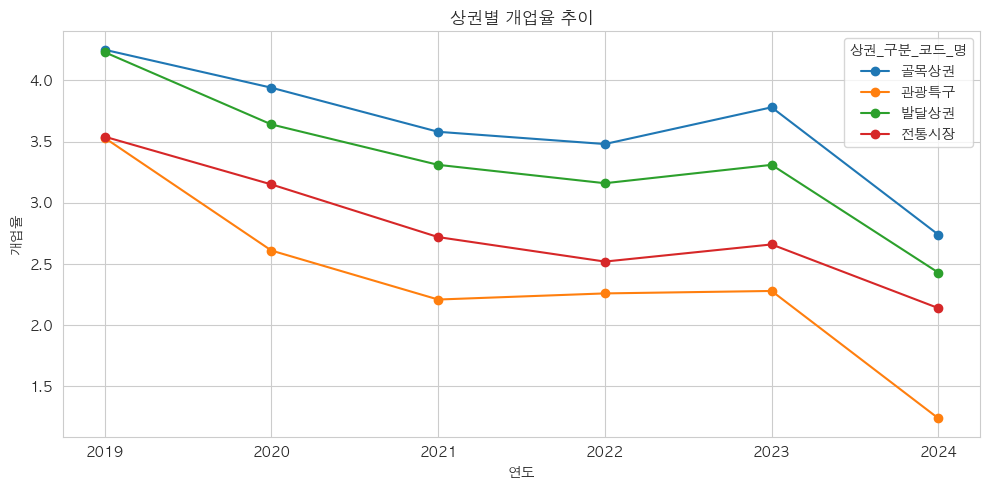

In [56]:
pivot_open.T.plot(kind='line', figsize=(10, 5), marker='o')
plt.title('상권별 개업율 추이')
plt.ylabel('개업율')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# 상권별 순성장률

* 상권유형별 순성장률

In [57]:
# 전체기준 순성장률
# 개업률/폐업률 -> 각분기 평균이 아니라 전체기간 비율이다.
전체 = df_전체.groupby('상권_구분_코드_명').agg(
    총개업수=('개업_점포_수', 'sum'),
    총폐업수=('폐업_점포_수', 'sum'),
    총점포수=('점포_수', 'sum')
).reset_index()

전체['개업율'] = 전체['총개업수'] / 전체['총점포수'] * 100
전체['폐업율'] = 전체['총폐업수'] / 전체['총점포수'] * 100

전체['순성장률'] = 전체['개업율'] - 전체['폐업율']

상권_구분_순성장률 = 전체[
    ['상권_구분_코드_명', '개업율', '폐업율', '순성장률']
]

상권_구분_순성장률

,상권_구분_코드_명,개업율,폐업율,순성장률
0,골목상권,3.62,3.08,0.53
1,관광특구,2.36,2.37,-0.01
2,발달상권,3.33,2.73,0.59
3,전통시장,2.78,2.67,0.12


In [58]:
연도별 = df_전체.groupby(['연도', '상권_구분_코드_명']).agg(
    총개업수=('개업_점포_수', 'sum'),
    총폐업수=('폐업_점포_수', 'sum'),
    총점포수=('점포_수', 'sum')
).reset_index()

연도별['개업율'] = 연도별['총개업수'] / 연도별['총점포수'] * 100
연도별['폐업율'] = 연도별['총폐업수'] / 연도별['총점포수'] * 100

연도별['순성장률'] = 연도별['개업율'] - 연도별['폐업율']

pivot = 연도별.pivot(
    index='상권_구분_코드_명',
    columns='연도',
    values='순성장률'
)

print(pivot)

연도          2019  2020  2021  2022  2023  2024
상권_구분_코드_명                                    
골목상권        1.11  1.02  0.61  0.73  0.51 -0.69
관광특구        1.07 -0.11 -0.29  0.31  0.02 -1.08
발달상권        1.35  0.81  0.67  0.73  0.53 -0.42
전통시장        0.65  0.35  0.20  0.19  0.00 -0.70


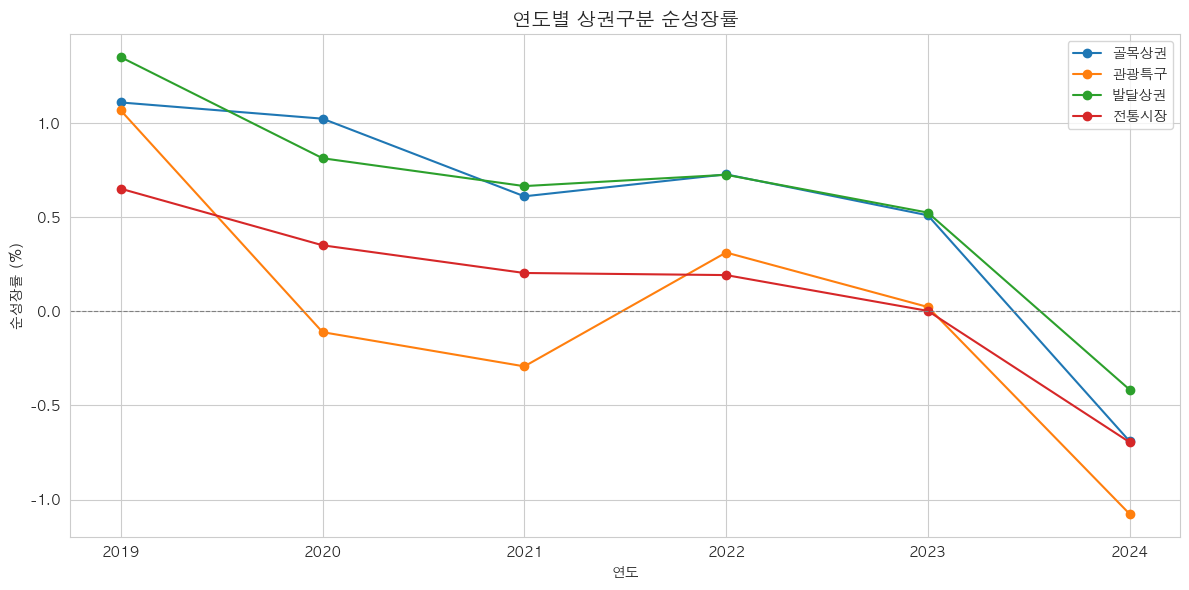

In [59]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 6))

for 상권 in pivot.index:
    ax.plot(pivot.columns, pivot.loc[상권], marker='o', label=상권)

ax.set_title('연도별 상권구분 순성장률', fontsize=14)
ax.set_xlabel('연도')
ax.set_ylabel('순성장률 (%)')
ax.axhline(y=0, color='gray', linestyle='--', linewidth=0.8)  # 0 기준선
ax.legend(loc='best')
plt.tight_layout()
plt.show()

* 상권명별 순성장률

In [60]:
# 전체기준 순성장률
# 개업률/폐업률 -> 각분기 평균이 아니라 전체기간 비율이다.
전체 = df_전체.groupby('상권_코드_명').agg(
    총개업수=('개업_점포_수', 'sum'),
    총폐업수=('폐업_점포_수', 'sum'),
    총점포수=('점포_수', 'sum')
).reset_index()

전체['개업율'] = 전체['총개업수'] / 전체['총점포수'] * 100
전체['폐업율'] = 전체['총폐업수'] / 전체['총점포수'] * 100

전체['순성장률'] = 전체['개업율'] - 전체['폐업율']

상권_순성장률 = 전체[
    ['상권_코드_명', '개업율', '폐업율', '순성장률']
]

상권_순성장률.head(20)

,상권_코드_명,개업율,폐업율,순성장률
0,4.19민주묘지역 2번,4.30,3.67,0.63
1,63빌딩,1.90,1.67,0.23
2,DMC(디지털미디어시티),5.08,4.20,0.88
3,GS강동자이아파트,3.78,2.81,0.97
4,G타워,4.65,2.51,2.14
5,KB국민은행 망원동지점,3.22,2.96,0.25
6,KB국민은행 서강지점,2.97,2.17,0.80
7,KB국민은행 종암동지점,2.15,2.45,-0.31
8,KB국민은행 중화동지점,2.60,1.79,0.81
9,KC대학교,4.99,3.81,1.18


In [61]:
top_growth    = 상권_순성장률.nlargest(15, '순성장률').reset_index(drop=True)
bottom_growth = 상권_순성장률.nsmallest(15, '순성장률').reset_index(drop=True)

display(top_growth)
display(bottom_growth)

,상권_코드_명,개업율,폐업율,순성장률
0,상계역전종합상가,30.11,10.75,19.35
1,하나고등학교,6.99,2.40,4.59
2,마곡역(마곡),7.19,2.87,4.32
3,서울숲카페거리,7.06,2.89,4.17
4,서울숲역 1번,6.58,2.48,4.10
5,신내역 2번,5.53,1.67,3.86
6,고덕 골목형상점가,6.94,3.22,3.72
7,문이교,6.29,2.69,3.59
8,싸리고개근린공원,5.07,1.69,3.38
9,은곡마을(은곡마을공원),8.19,4.83,3.37


,상권_코드_명,개업율,폐업율,순성장률
0,은마종합상점가,1.10,4.40,-3.30
1,보광시장,1.84,5.13,-3.29
2,역촌중앙시장,1.07,4.28,-3.21
3,본동인정시장(기능상실),1.19,4.18,-2.99
4,박미시장(기능상실),1.45,4.35,-2.90
5,신림종합시장,2.26,5.01,-2.76
6,증산골목시장,0.75,3.49,-2.74
7,흑석2치안센터,2.19,4.57,-2.39
8,중대부중,1.01,3.30,-2.28
9,종암아이파크2차후문,0.45,2.73,-2.27


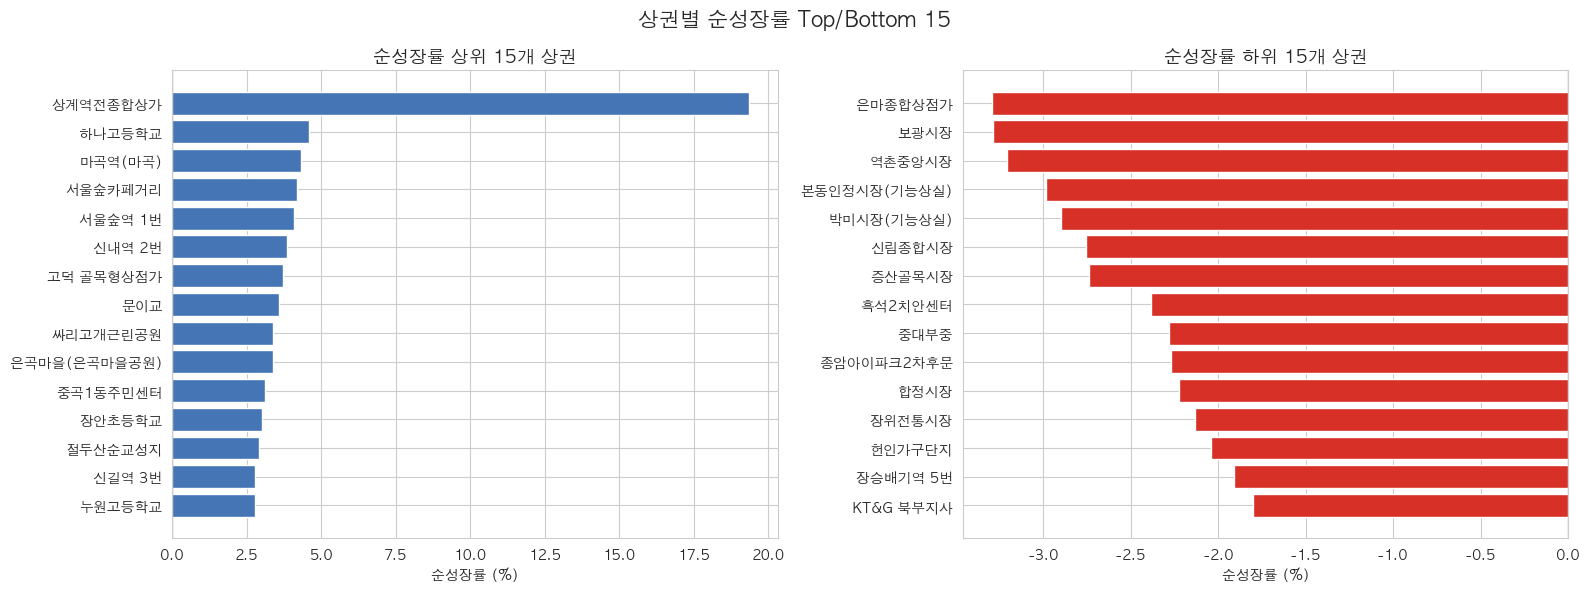

In [62]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top 15 성장 상권
top_sorted = top_growth.sort_values('순성장률', ascending=True)
axes[0].barh(top_sorted['상권_코드_명'], top_sorted['순성장률'], color='#4575b4')
axes[0].axvline(x=0, color='black', linewidth=0.8)
axes[0].set_title('순성장률 상위 15개 상권', fontsize=13)
axes[0].set_xlabel('순성장률 (%)')

# Bottom 15 쇠퇴 상권
bottom_sorted = bottom_growth.sort_values('순성장률', ascending=False)
axes[1].barh(bottom_sorted['상권_코드_명'], bottom_sorted['순성장률'], color='#d73027')
axes[1].axvline(x=0, color='black', linewidth=0.8)
axes[1].set_title('순성장률 하위 15개 상권', fontsize=13)
axes[1].set_xlabel('순성장률 (%)')

plt.suptitle('상권별 순성장률 Top/Bottom 15', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()